# <center>Project Title- “End-to-End Telecom Customer Churn Prediction using Machine learning, FastAPI, Streamlit and Docker”</center>

## Project Summary :

This project aims to build an end-to-end machine learning solution to predict customer churn in a telecommunications company. Customer churn prediction helps businesses identify customers who are likely to discontinue their services, enabling proactive retention strategies.

The project involves data preprocessing, exploratory data analysis (EDA), feature engineering, and training multiple machine learning models such as Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and others. Various models were evaluated to identify the most suitable approach for churn prediction.

Among all models, the Random Forest model was selected as the final model due to its strong performance in identifying churn customers. A complete machine learning pipeline was developed to automate data preprocessing and prediction, ensuring consistency and reducing manual errors.

The solution was deployed using FastAPI for backend API development, Streamlit for building an interactive user interface, and Docker for containerization. This makes the application scalable, portable, and production-ready.

Overall, this project demonstrates the complete lifecycle of a machine learning solution, from data analysis to deployment, providing a practical tool for customer retention in the telecom industry.


## GitHub Link :

https://github.com/chetansgode/Telcom_Customer_Churn_Analysis.git

## Problem Statement :

Customer churn is a major challenge for telecom companies, as losing existing customers directly impacts revenue and business growth. Many customers discontinue telecom services due to factors such as high charges, poor service quality, or better offers from competitors. However, identifying which customers are likely to leave in advance is difficult using traditional analysis methods. The problem is to develop a machine learning model that can analyze customer demographic information, service usage patterns, and billing details to predict whether a customer is likely to churn. This predictive system can help telecom companies take proactive actions to retain customers and improve overall customer satisfaction.

## Import Libraries :

In [1]:
# for data processing
import numpy as np 
import pandas as pd 
# for visualisation of data 
import matplotlib.pyplot as plt 
import seaborn as sns 
#filter warnings
import warnings
warnings.filterwarnings('ignore')
#set max columns display in pandas 
pd.set_option("display.max_columns", 40)
#to preprocessing data
from sklearn.preprocessing import PowerTransformer,OneHotEncoder,LabelEncoder,MinMaxScaler,OrdinalEncoder  #OneHotEncoder>Multicategory,LabelEncoder>binary,map():know variable
#to balance class imbalance 
from imblearn.over_sampling import SMOTE
#for features selection 
from statsmodels.stats.outliers_influence import variance_inflation_factor
#for dividing data
from sklearn.model_selection import train_test_split,GridSearchCV
#model importing
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier, export_graphviz  #To visualize the decision tree, you can use the export_graphviz function.
from sklearn import tree                                #It is used to display the decision tree visualization as an SVG image.
from IPython.display import SVG                         #Yes, the IPython.display module allows you to display various types of content in IPython and Jupyter Notebook environments, including SVG (Scalable Vector Graphics) images. SVG is a format used for describing two-dimensional vector graphics.
from graphviz import Source
from IPython.display import display                            #To use the SVG function from IPython.display, you need to have IPython installed, which usually comes pre-installed with Jupyter Notebook.
from sklearn.ensemble import RandomForestClassifier  #bagging ensemble method
from sklearn.ensemble import GradientBoostingClassifier   #boosting ensemble method   
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
#for evaluation of model
from sklearn.metrics import accuracy_score,precision_score,recall_score,roc_auc_score,confusion_matrix
#model explainability models for black box
import lime
from lime.lime_tabular import LimeTabularExplainer
import shap
#for ml pipelines
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from imblearn.pipeline import Pipeline
import os
#to save models 
import joblib

## Loading Dataset : 

In [2]:
#loading data
df=pd.read_csv("../datasets\WA_Fn-UseC_-Telco-Customer-Churn.csv")    #..> for goback to main directory

## Variables Description:

customerID :	Unique ID assigned to each customer

gender :	Customer's gender (Male/Female)

SeniorCitizen :	Indicates if the customer is a senior citizen (1 = Yes, 0 = No)

Partner :	Whether the customer has a partner (Yes/No)

Dependents :	Whether the customer has dependents (Yes/No)

tenure :	Number of months the customer has stayed with the company

PhoneService :	Whether the customer has phone service (Yes/No)

MultipleLines :	Whether the customer has multiple phone lines (Yes/No/No phone service)

InternetService :	Type of internet service (DSL, Fiber optic, No)

OnlineSecurity :	Whether the customer has online security service

OnlineBackup :	Whether the customer has online backup

DeviceProtection :	Whether the customer has device protection

TechSupport	: Whether the customer has technical support

StreamingTV : 	Whether the customer has TV streaming service

StreamingMovies :	Whether the customer has movie streaming service

Contract :	Type of contract (Month-to-month, One year, Two year)

PaperlessBilling :	Whether the customer uses paperless billing (Yes/No)

PaymentMethod :	Customer payment method (Credit card, Bank transfer, Electronic check, Mailed check)

MonthlyCharges :	Amount charged to the customer every month

TotalCharges :	Total amount charged to the customer

Churn :	Indicates if the customer left the company (Yes = Churn, No = Stayed)

## Dataset First View :

In [3]:
#checking data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### Dataset Shape :

In [4]:
print(F"Shape of available data : {df.shape}") 
print(f"No of features in data : {df.shape[1]}\nNo of records in data : {df.shape[0]}")

Shape of available data : (7043, 21)
No of features in data : 21
No of records in data : 7043


#### Dataset Duplicate check :

In [5]:
print(f"Checking duplicate record in dataset : {df.duplicated().sum()}")

Checking duplicate record in dataset : 0


#### Checking Null values in datasets :

In [6]:
print('Checking total null value in each feature :\n')
print(pd.DataFrame(df.isna().sum(),columns=[['Sum of Null values']]))

Checking total null value in each feature :

                 Sum of Null values
customerID                        0
gender                            0
SeniorCitizen                     0
Partner                           0
Dependents                        0
tenure                            0
PhoneService                      0
MultipleLines                     0
InternetService                   0
OnlineSecurity                    0
OnlineBackup                      0
DeviceProtection                  0
TechSupport                       0
StreamingTV                       0
StreamingMovies                   0
Contract                          0
PaperlessBilling                  0
PaymentMethod                     0
MonthlyCharges                    0
TotalCharges                      0
Churn                             0


#### Checking data types :

In [7]:
print('Checking data types of each features :\n')
df.info()

Checking data types of each features :

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBill

#### Data Cleaning :

In [8]:
#Changing data type of TotalCharges  
print(f"data types of TotalCharges is : {df['TotalCharges'].dtypes}\n")

print('Some record has no data  :\n')
print(df[df['TotalCharges'].str.isspace()][['customerID','TotalCharges']])

#checking data distribution without space data 

print(f"\nData distribution by ignoring space record :\n{df[~df['TotalCharges'].str.isspace()]['TotalCharges'].astype('float').describe()}")

#Convert data type from string str to float

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
#don't use median because all data has tenure=0 so select recent monthly charge 
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])    


data types of TotalCharges is : str

Some record has no data  :

      customerID TotalCharges
488   4472-LVYGI             
753   3115-CZMZD             
936   5709-LVOEQ             
1082  4367-NUYAO             
1340  1371-DWPAZ             
3331  7644-OMVMY             
3826  3213-VVOLG             
4380  2520-SGTTA             
5218  2923-ARZLG             
6670  4075-WKNIU             
6754  2775-SEFEE             

Data distribution by ignoring space record :
count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64


#### Checking MonthlyCharges has outlier or not (iqr):

Upper and Lower range for Outlier is : 171.38,-46.02 and our data max: 118.75 and min: 18.25 record value within range so no outlier present


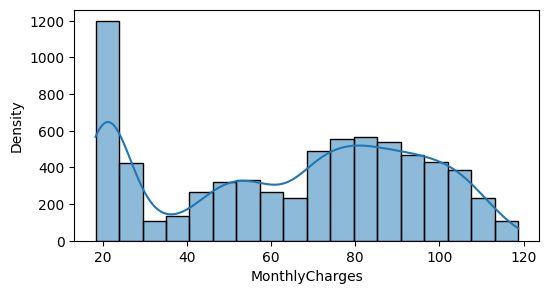

In [9]:
#checking outlier in data or not  bu iqr (Q3-Q1)
iqr=(df['MonthlyCharges'].quantile(0.75) -df['MonthlyCharges'].quantile(0.25))*1.5
upper_layer=round(df['MonthlyCharges'].quantile(0.75)+iqr,2)
lower_layer=round(df['MonthlyCharges'].quantile(0.25)-iqr,2)
print(f"Upper and Lower range for Outlier is : {upper_layer},{lower_layer} and \
our data max: {df['MonthlyCharges'].max()} and min: {df['MonthlyCharges'].min()} \
record value within range so no outlier present")

#data distribution
plt.figure(figsize=(6,3))
sns.histplot(df['MonthlyCharges'],kde=True)
plt.xlabel('MonthlyCharges')
plt.ylabel('Density') 
plt.show()


## EDA

#### 1) Analyse how many customer has left the service by gender ?

In [10]:
# Analysis how many churn gender wise 
data_genderwise_churn=df.groupby(['gender','Churn']).size().reset_index().rename(columns={0 :'total_count'}).set_index('gender')
print(data_genderwise_churn)
#check average total churn gender wise
churn_counts = data_genderwise_churn.reset_index().groupby('Churn')['total_count'].sum()
#check female wise churn
female_df = data_genderwise_churn.reset_index().iloc[:2]
#check male wise churn
male_df = data_genderwise_churn.reset_index().iloc[2:]

       Churn  total_count
gender                   
Female    No         2549
Female   Yes          939
Male      No         2625
Male     Yes          930


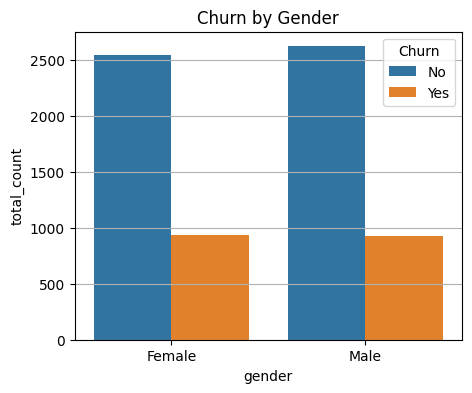

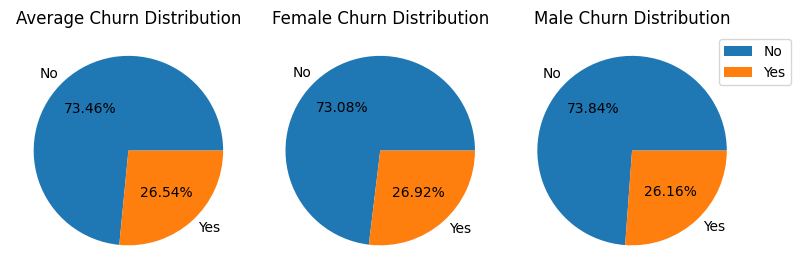

In [11]:
#bar plot for customer churn 
plt.figure(figsize=(5,4))
sns.barplot(data=data_genderwise_churn, x='gender', y='total_count', hue='Churn')
plt.title("Churn by Gender")
plt.grid(visible= True,axis='y')
plt.show()


plt.figure(figsize=(8,3))
plt.subplot(1,3,1)
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.2f%%')
plt.title("Average Churn Distribution")

plt.subplot(1,3,2)
plt.title("Female Churn Distribution")
plt.pie(
    female_df['total_count'],
    labels=female_df['Churn'],
    autopct='%1.2f%%'
)

plt.subplot(1,3,3)
plt.title("Male Churn Distribution")
plt.pie(
    male_df['total_count'],
    labels=male_df['Churn'],
    autopct='%1.2f%%'
)

plt.legend(loc='upper right',bbox_to_anchor=(1.2,1))
plt.tight_layout()
plt.show()

##### Insight>>>


In [12]:
print('Insight :\n')
print(f"Total active user  Male is higher than Female by {data_genderwise_churn.reset_index().iloc[2,2]-data_genderwise_churn.reset_index().iloc[0,2]}\n")
print(f"Churn is Famale is higher than male by {round(26.92-26.16,2)}%")

Insight :

Total active user  Male is higher than Female by 76

Churn is Famale is higher than male by 0.76%


#### 2) Analyse how many customer has left the service by SeniorCitizen,Partner and PaperlessBilling ?


SeniorCitizen

Churn data categories by subcategories of  SeniorCitizen :

              Churn  total_count
SeniorCitizen                   
0                No         4508
0               Yes         1393
1                No          666
1               Yes          476

Churn data categories by SeniorCitizen except subcategory 0 & 1 :

Churn
No     5174
Yes    1869
Name: total_count, dtype: int64

Churn data category by selecting 0 one of subcategory of SeniorCitizen :

   SeniorCitizen Churn  total_count
0              0    No         4508
1              0   Yes         1393

Churn data category by selecting 1 one of subcategory of SeniorCitizen :

   SeniorCitizen Churn  total_count
2              1    No          666
3              1   Yes          476


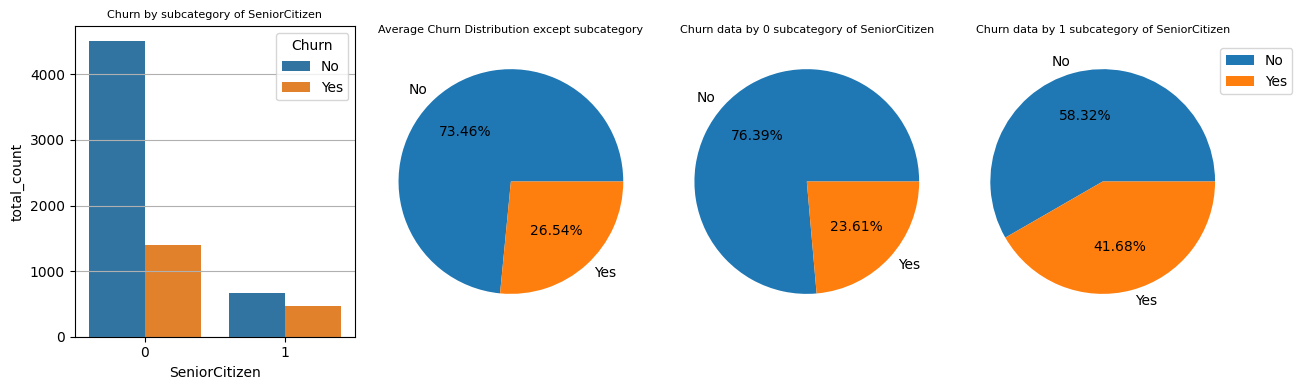

------------------------------------------------------------------------------------------------------------------------------------------------------

Partner

Churn data categories by subcategories of  Partner :

        Churn  total_count
Partner                   
No         No         2441
No        Yes         1200
Yes        No         2733
Yes       Yes          669

Churn data categories by Partner except subcategory No & Yes :

Churn
No     5174
Yes    1869
Name: total_count, dtype: int64

Churn data category by selecting No one of subcategory of Partner :

  Partner Churn  total_count
0      No    No         2441
1      No   Yes         1200

Churn data category by selecting Yes one of subcategory of Partner :

  Partner Churn  total_count
2     Yes    No         2733
3     Yes   Yes          669


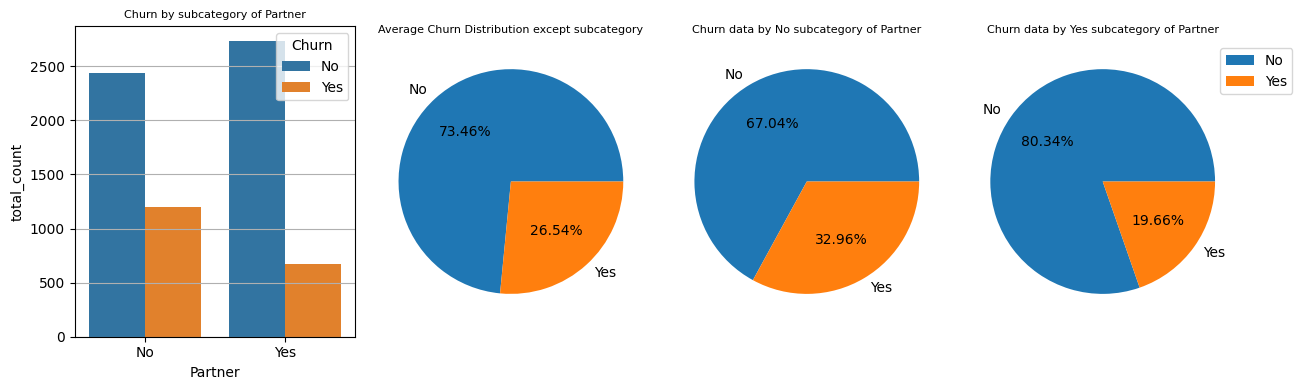

------------------------------------------------------------------------------------------------------------------------------------------------------

PaperlessBilling

Churn data categories by subcategories of  PaperlessBilling :

                 Churn  total_count
PaperlessBilling                   
No                  No         2403
No                 Yes          469
Yes                 No         2771
Yes                Yes         1400

Churn data categories by PaperlessBilling except subcategory No & Yes :

Churn
No     5174
Yes    1869
Name: total_count, dtype: int64

Churn data category by selecting No one of subcategory of PaperlessBilling :

  PaperlessBilling Churn  total_count
0               No    No         2403
1               No   Yes          469

Churn data category by selecting Yes one of subcategory of PaperlessBilling :

  PaperlessBilling Churn  total_count
2              Yes    No         2771
3              Yes   Yes         1400


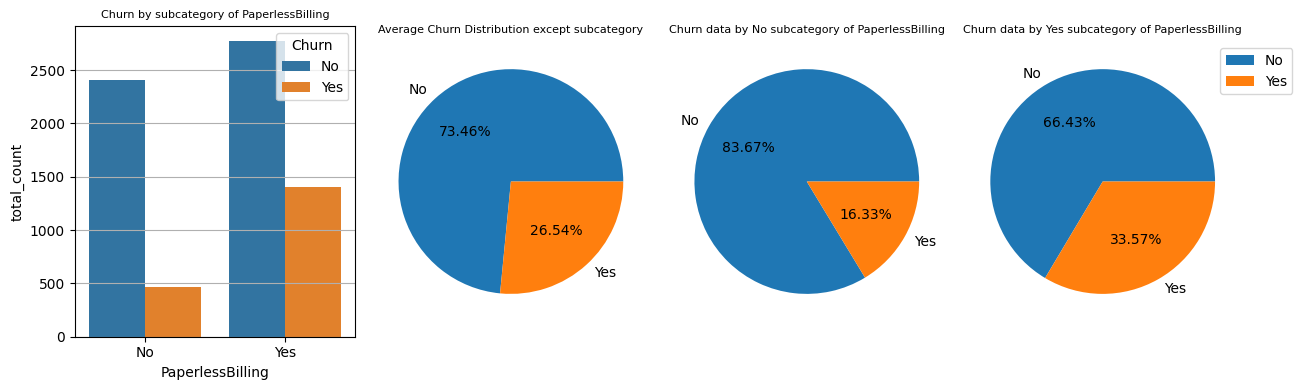

------------------------------------------------------------------------------------------------------------------------------------------------------


In [13]:
for i in ['SeniorCitizen','Partner','PaperlessBilling']:
    print(f"\n{i}\n")
    # Analysis how many churn 
    df1=df.groupby([i,'Churn']).size().reset_index().rename(columns={0 :'total_count'}).set_index(i)
    print(f'Churn data categories by subcategories of  {i} :\n')
    print(df1)
    
    #churn data categories by {i} except subcategory
    df2 = df1.reset_index().groupby('Churn')['total_count'].sum()
    #check sub category churn distribution
    df3 = df1.reset_index().iloc[:2]
    #check sub category churn distribution
    df4 = df1.reset_index().iloc[2:] 

    print(f'\nChurn data categories by {i} except subcategory {df3[i].iloc[0]} & {df4[i].iloc[0]} :\n')
    print(df2)
    print(f'\nChurn data category by selecting {df3[i].iloc[0]} one of subcategory of {i} :\n')
    print(df3)
    print(f'\nChurn data category by selecting {df4[i].iloc[0]} one of subcategory of {i} :\n')
    print(df4)

    plt.figure(figsize=(13,4))
    
    #bar plot for customer churn
    plt.subplot(1,4,1)
    sns.barplot(data=df1, x=i, y='total_count', hue='Churn')
    plt.title(f"Churn by subcategory of {i}",fontsize=8)
    plt.grid(visible= True,axis='y')



    plt.subplot(1,4,2)
    plt.pie(df2, labels=churn_counts.index, autopct='%1.2f%%')
    plt.title(f"Average Churn Distribution except subcategory",fontsize=8)
    
    plt.subplot(1,4,3)
    plt.title(f"Churn data by {df3[i].iloc[0]} subcategory of {i}",fontsize=8)
    plt.pie(
        df3['total_count'],
        labels=df3['Churn'],
        autopct='%1.2f%%'
    )
    
    plt.subplot(1,4,4)
    plt.title(f"Churn data by {df4[i].iloc[0]} subcategory of {i}",fontsize=8)
    plt.pie(
        df4['total_count'],
        labels=df4['Churn'],
        autopct='%1.2f%%'
    )
    
    plt.legend(loc='upper right',bbox_to_anchor=(1.2,1))
    plt.tight_layout()
    plt.show()

    print("-"*150)
    

##### Insight>>>

In [14]:
print('Insight :\n')
print('For SeniorCitizen')
print("Totat churn by SeniorCitizen is 26.54 %")
print("Total churn by No Subcategory of SeniorCitizen is 23.61 %")
print("Total churn by Yes subcategory of SeniorCitizen is 41.68 % and which is higher than no subcategory by 18.07 %")
print('\nFor Partner')
print("Totat churn by Partner is 26.54 %")
print("Total churn by No Subcategory of Partner is 32.96 % and which is higher than no subcategory by 13.3 %")
print("Total churn by Yes subcategory of Partner is 19.66 % ")
print('\nFor PaperlessBilling ')
print("Totat churn by PaperlessBilling  is 26.54 %")
print("Total churn by No Subcategory of PaperlessBilling  is 16.33 % ")
print("Total churn by Yes subcategory of PaperlessBilling  is 33.57 % and which is higher than no subcategory by 17.24 %")

Insight :

For SeniorCitizen
Totat churn by SeniorCitizen is 26.54 %
Total churn by No Subcategory of SeniorCitizen is 23.61 %
Total churn by Yes subcategory of SeniorCitizen is 41.68 % and which is higher than no subcategory by 18.07 %

For Partner
Totat churn by Partner is 26.54 %
Total churn by No Subcategory of Partner is 32.96 % and which is higher than no subcategory by 13.3 %
Total churn by Yes subcategory of Partner is 19.66 % 

For PaperlessBilling 
Totat churn by PaperlessBilling  is 26.54 %
Total churn by No Subcategory of PaperlessBilling  is 16.33 % 
Total churn by Yes subcategory of PaperlessBilling  is 33.57 % and which is higher than no subcategory by 17.24 %


short tenure churn more
contract type affect churn
payment method has the highest churn
internet service type affect churn
tech support reduce churn
online security churn less
monthly charges churn more
TotalCharges and churn

#### 3) Analysis how customer churn is affected by Contract,InternetService,TechSupport and OnlineSecurity variable?


Contract :

checking total data distribution of Contract with category :

         Contract  total_count
0  Month-to-month         3875
1        One year         1473
2        Two year         1695
checking subcategory wise data distribution of features Contract :

         Contract Churn  total_count
0  Month-to-month    No         2220
1  Month-to-month   Yes         1655
2        One year    No         1307
3        One year   Yes          166
4        Two year    No         1647
5        Two year   Yes           48
selecting one of subcatagory Month-to-month wise data distributions of Contract :

         Contract Churn  total_count
0  Month-to-month    No         2220
1  Month-to-month   Yes         1655
selecting one of subcatagory One year wise data distributions of Contract :

   Contract Churn  total_count
2  One year    No         1307
3  One year   Yes          166
selecting one of subcatagory Two year wise data distributions of Contract :

   Contract Churn  total_count
4 

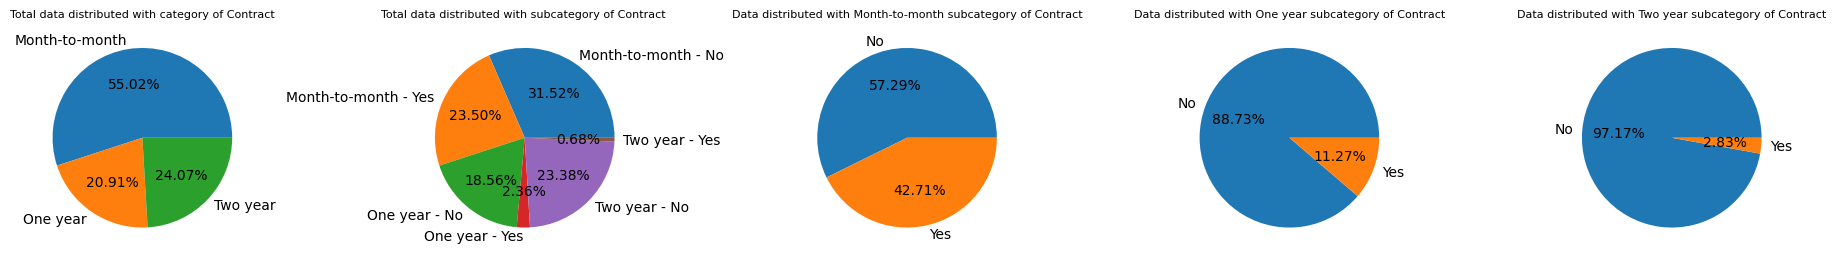

-----------------------------------------------------------------------------------------------------------------------------------------------------

InternetService :

checking total data distribution of InternetService with category :

  InternetService  total_count
0             DSL         2421
1     Fiber optic         3096
2              No         1526
checking subcategory wise data distribution of features InternetService :

  InternetService Churn  total_count
0             DSL    No         1962
1             DSL   Yes          459
2     Fiber optic    No         1799
3     Fiber optic   Yes         1297
4              No    No         1413
5              No   Yes          113
selecting one of subcatagory DSL wise data distributions of InternetService :

  InternetService Churn  total_count
0             DSL    No         1962
1             DSL   Yes          459
selecting one of subcatagory Fiber optic wise data distributions of InternetService :

  InternetService Churn  t

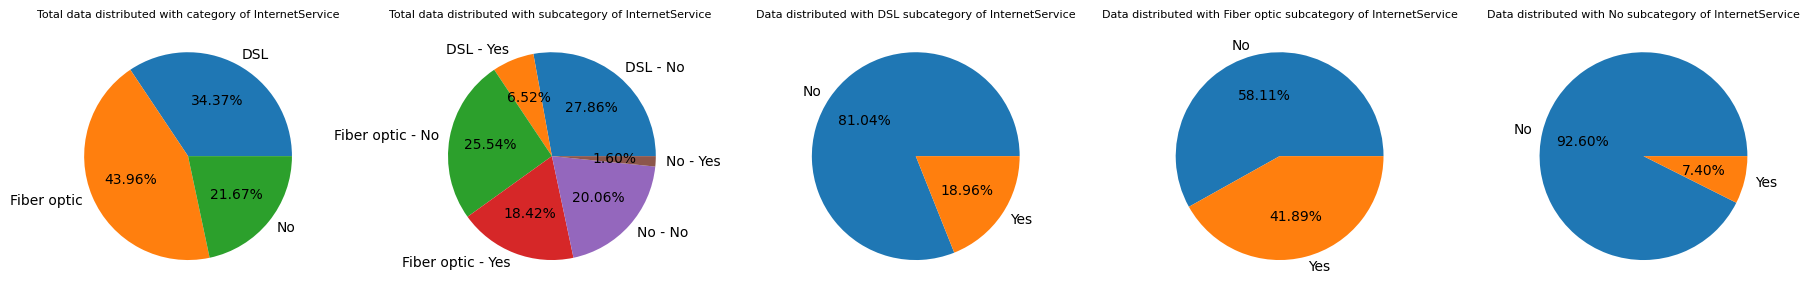

-----------------------------------------------------------------------------------------------------------------------------------------------------

TechSupport :

checking total data distribution of TechSupport with category :

           TechSupport  total_count
0                   No         3473
1  No internet service         1526
2                  Yes         2044
checking subcategory wise data distribution of features TechSupport :

           TechSupport Churn  total_count
0                   No    No         2027
1                   No   Yes         1446
2  No internet service    No         1413
3  No internet service   Yes          113
4                  Yes    No         1734
5                  Yes   Yes          310
selecting one of subcatagory No wise data distributions of TechSupport :

  TechSupport Churn  total_count
0          No    No         2027
1          No   Yes         1446
selecting one of subcatagory No internet service wise data distributions of TechSupport

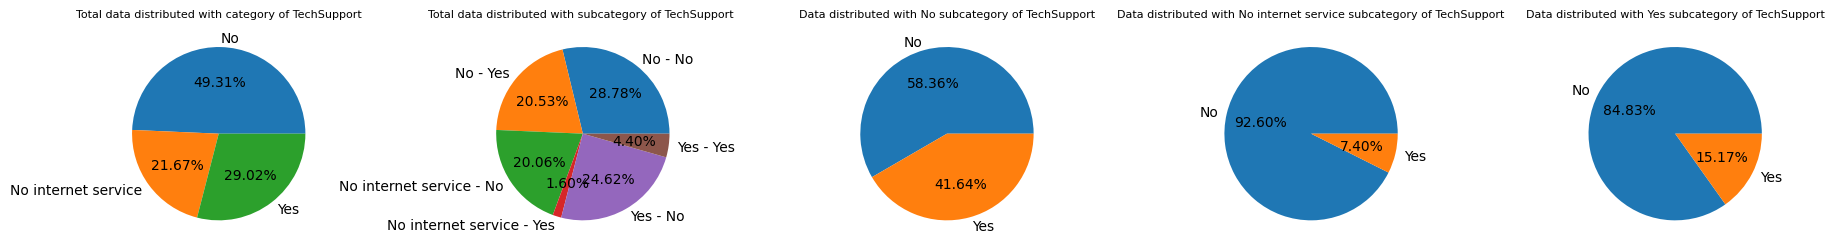

-----------------------------------------------------------------------------------------------------------------------------------------------------

OnlineSecurity :

checking total data distribution of OnlineSecurity with category :

        OnlineSecurity  total_count
0                   No         3498
1  No internet service         1526
2                  Yes         2019
checking subcategory wise data distribution of features OnlineSecurity :

        OnlineSecurity Churn  total_count
0                   No    No         2037
1                   No   Yes         1461
2  No internet service    No         1413
3  No internet service   Yes          113
4                  Yes    No         1724
5                  Yes   Yes          295
selecting one of subcatagory No wise data distributions of OnlineSecurity :

  OnlineSecurity Churn  total_count
0             No    No         2037
1             No   Yes         1461
selecting one of subcatagory No internet service wise data distrib

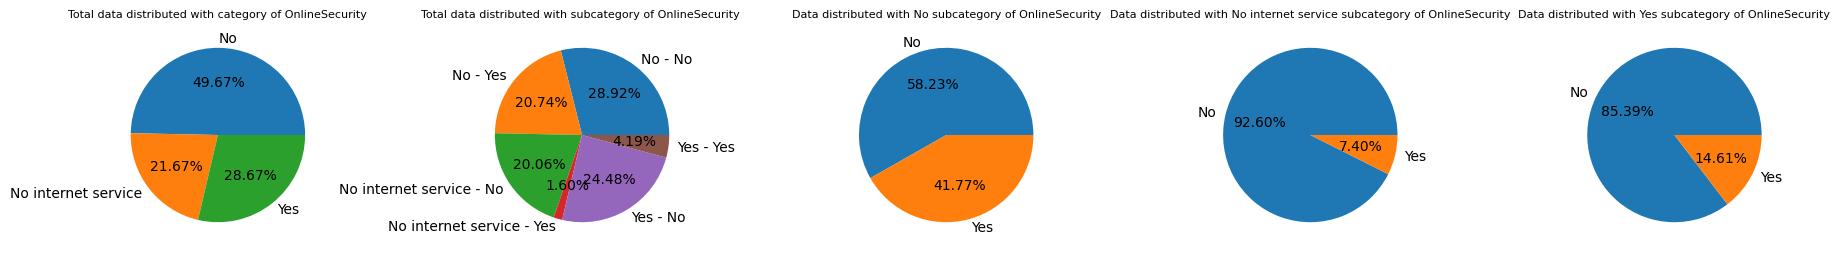

-----------------------------------------------------------------------------------------------------------------------------------------------------


In [15]:
#checking total data distribution with category
for i in ['Contract','InternetService','TechSupport','OnlineSecurity']:
    print(f"\n{i} :\n")
    df1=df.groupby(i)['Churn'].size().reset_index().rename(columns={'Churn':'total_count'})
    #checking subcategory wise data distribution of features
    df2=df.groupby([i,'Churn']).size().reset_index().rename(columns={0:'total_count'})
    #selecting one of subcatagory wise data distributions
    df3=df.groupby([i,'Churn']).size().reset_index().rename(columns={0:'total_count'})[:2]
    df4=df.groupby([i,'Churn']).size().reset_index().rename(columns={0:'total_count'})[2:4]
    df5=df.groupby([i,'Churn']).size().reset_index().rename(columns={0:'total_count'})[4:]
    print(f"checking total data distribution of {i} with category :\n")
    print(df1)
    print(f"checking subcategory wise data distribution of features {i} :\n")
    print(df2)
    print(f"selecting one of subcatagory { df3.iloc[0,0] } wise data distributions of {i} :\n")
    print(df3)
    print(f"selecting one of subcatagory { df4.iloc[0,0] } wise data distributions of {i} :\n")
    print(df4)
    print(f"selecting one of subcatagory { df5.iloc[0,0] } wise data distributions of {i} :\n")
    print(df5)

    plt.figure(figsize=(18,4))
    #category wise data distribute
    plt.subplot(1,5,1)
    plt.pie(df1['total_count'],labels=df1[i],autopct='%1.2f%%')
    plt.title(f'Total data distributed with category of {i}',fontsize=8)

    #plot subcategory wise data distribution
    plt.subplot(1,5,2)
    plt.pie(df2['total_count'],labels=df2[i] + " - " + df2['Churn'],autopct='%1.2f%%')
    plt.title(f"Total data distributed with subcategory of {i} ",fontsize=8)

    #plot one of subcategory data distribution
    plt.subplot(1,5,3)
    plt.pie(df3['total_count'],labels= df3['Churn'],autopct='%1.2f%%') 
    plt.title(f"Data distributed with { df3.iloc[0,0] } subcategory of {i}",fontsize=8)
    
    #plot one of subcategory data distribution
    plt.subplot(1,5,4)
    plt.pie(df4['total_count'],labels= df4['Churn'],autopct='%1.2f%%') 
    plt.title(f"Data distributed with { df4.iloc[0,0] } subcategory of {i}",fontsize=8) 

    #plot one of subcategory data distribution
    plt.subplot(1,5,5)
    plt.pie(df5['total_count'],labels= df5['Churn'],autopct='%1.2f%%') 
    plt.title(f"Data distributed with { df5.iloc[0,0] } subcategory of {i}",fontsize=8)
    plt.tight_layout()
   
    plt.show()
    print("-"*149)

##### Insight>>>

In [16]:
print("Insight :\n")
print('Contract :')
print("Totol data distributed with subcategories of 'Contract' variable has min percentage of 'One Year' and max percentage of 'Month-to-month'")
print("Max customer churn rate in 'Month to month' type and min in 'Two year' type of 'contract' ")
print('\nInternetService :')
print("Totol data distributed with subcategories of 'InternetService' variable has min percentage of 'No' and max percentage of 'Fiber optic'")
print("Max customer churn rate in 'Fiber optic' type and min in 'No' type of 'InternetService' ")
print('\nTechSupport :')
print("Totol data distributed with subcategories of 'TechSupport' variable has min percentage of 'No internet service' and max percentage of 'No'")
print("Max customer churn rate in 'No' type and min in 'No internet service' type of 'TechSupport' ")
print('\nOnlineSecurity :')
print("Totol data distributed with subcategories of 'OnlineSecurity' variable has min percentage of 'No internet service' and max percentage of 'No'")
print("Max customer churn rate in 'No' type and min in 'No internet service' type of 'OnlineSecurity' ")


Insight :

Contract :
Totol data distributed with subcategories of 'Contract' variable has min percentage of 'One Year' and max percentage of 'Month-to-month'
Max customer churn rate in 'Month to month' type and min in 'Two year' type of 'contract' 

InternetService :
Totol data distributed with subcategories of 'InternetService' variable has min percentage of 'No' and max percentage of 'Fiber optic'
Max customer churn rate in 'Fiber optic' type and min in 'No' type of 'InternetService' 

TechSupport :
Totol data distributed with subcategories of 'TechSupport' variable has min percentage of 'No internet service' and max percentage of 'No'
Max customer churn rate in 'No' type and min in 'No internet service' type of 'TechSupport' 

OnlineSecurity :
Totol data distributed with subcategories of 'OnlineSecurity' variable has min percentage of 'No internet service' and max percentage of 'No'
Max customer churn rate in 'No' type and min in 'No internet service' type of 'OnlineSecurity' 


#### 4) Analysis how customer churn is affected by PaymentMethod

In [17]:
#checking data churn distribution of PaymentMethod variable
df1=df.groupby('PaymentMethod')['Churn'].size().reset_index().rename(columns={'Churn':'total_count'})
#checking subcategory wise data distribution of features
df2=df.groupby(['PaymentMethod','Churn']).size().reset_index().rename(columns={0:'total_count'})
#selecting one of subcatagory wise data distributions
df3=df.groupby(['PaymentMethod','Churn']).size().reset_index().rename(columns={0:'total_count'})[:2]
df4=df.groupby(['PaymentMethod','Churn']).size().reset_index().rename(columns={0:'total_count'})[2:4]
df5=df.groupby(['PaymentMethod','Churn']).size().reset_index().rename(columns={0:'total_count'})[4:6]
df6=df.groupby(['PaymentMethod','Churn']).size().reset_index().rename(columns={0:'total_count'})[6:]
print(f"\nChecking total data distribution of PaymentMethod with category :")
print(df1)
print(f"\nChecking subcategory wise data distribution of features PaymentMethod :")
print(df2)
print(f"\nSelecting one of subcatagory { df3.iloc[0,0] } wise data distributions of PaymentMethod :")
print(df3)
print(f"\nSelecting one of subcatagory { df4.iloc[0,0] } wise data distributions of PaymentMethod :")
print(df4)
print(f"\nSelecting one of subcatagory { df5.iloc[0,0] } wise data distributions of PaymentMethod :")
print(df5)
print(f"\nSelecting one of subcatagory { df6.iloc[0,0] } wise data distributions of PaymentMethod :")
print(df6)





Checking total data distribution of PaymentMethod with category :
               PaymentMethod  total_count
0  Bank transfer (automatic)         1544
1    Credit card (automatic)         1522
2           Electronic check         2365
3               Mailed check         1612

Checking subcategory wise data distribution of features PaymentMethod :
               PaymentMethod Churn  total_count
0  Bank transfer (automatic)    No         1286
1  Bank transfer (automatic)   Yes          258
2    Credit card (automatic)    No         1290
3    Credit card (automatic)   Yes          232
4           Electronic check    No         1294
5           Electronic check   Yes         1071
6               Mailed check    No         1304
7               Mailed check   Yes          308

Selecting one of subcatagory Bank transfer (automatic) wise data distributions of PaymentMethod :
               PaymentMethod Churn  total_count
0  Bank transfer (automatic)    No         1286
1  Bank transfer (autom

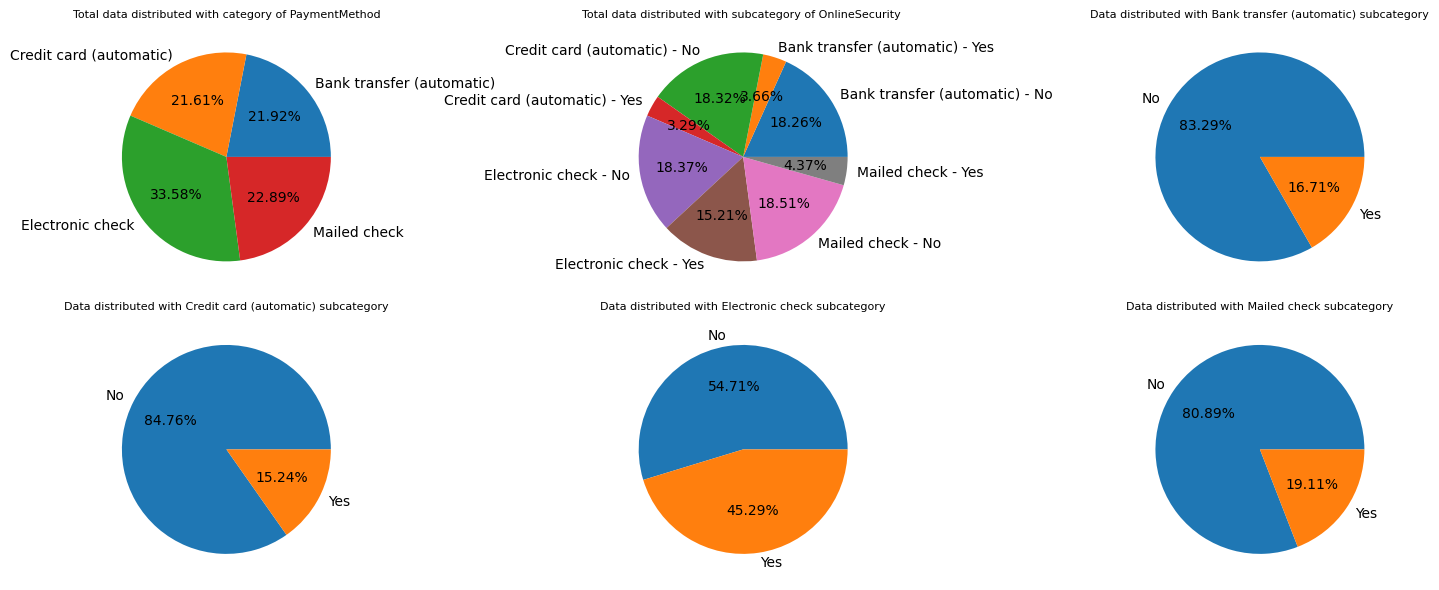

In [18]:
#figure
plt.figure(figsize=(14,6))
#category wise data distribute
plt.subplot(2,3,1)
plt.pie(df1['total_count'],labels=df1['PaymentMethod'],autopct='%1.2f%%')
plt.title(f'Total data distributed with category of PaymentMethod',fontsize=8)

#plot subcategory wise data distribution
plt.subplot(2,3,2)
plt.pie(df2['total_count'],labels=df2['PaymentMethod'] + " - " + df2['Churn'],autopct='%1.2f%%')
plt.title(f"Total data distributed with subcategory of {i} ",fontsize=8)

#plot one of subcategory data distribution
plt.subplot(2,3,3)
plt.pie(df3['total_count'],labels= df3['Churn'],autopct='%1.2f%%') 
plt.title(f"Data distributed with { df3.iloc[0,0] } subcategory",fontsize=8)

#plot one of subcategory data distribution
plt.subplot(2,3,4)
plt.pie(df4['total_count'],labels= df4['Churn'],autopct='%1.2f%%') 
plt.title(f"Data distributed with { df4.iloc[0,0] } subcategory",fontsize=8) 

#plot one of subcategory data distribution
plt.subplot(2,3,5)
plt.pie(df5['total_count'],labels= df5['Churn'],autopct='%1.2f%%') 
plt.title(f"Data distributed with { df5.iloc[0,0] } subcategory",fontsize=8)

#plot one of subcategory data distribution
plt.subplot(2,3,6)
plt.pie(df6['total_count'],labels= df6['Churn'],autopct='%1.2f%%') 
plt.title(f"Data distributed with { df6.iloc[0,0] } subcategory",fontsize=8)
plt.tight_layout()

plt.show()

##### Insight>>>

In [19]:
print('Insight:\n')
print("Total data distributed of PaymentMethod by subcategory have max and min value for 'Electronic check','credit card (automatic)'\n")
print("Payment method subcategory has highest and lowest churn is 'Electronic check','Credit card (automatic)'")

Insight:

Total data distributed of PaymentMethod by subcategory have max and min value for 'Electronic check','credit card (automatic)'

Payment method subcategory has highest and lowest churn is 'Electronic check','Credit card (automatic)'


#### 5) Analysis of top and bottom 5 total Customer by tenure ?
#### 6) Analysis of top and bottom 5 tenure where highest and lowest churn of customer ?

In [20]:
#checking top and bottom 5 total customer by tenure
top_5=df.groupby('tenure').size().reset_index().rename(columns={0:'total_count'}).sort_values(['total_count']).tail(5)
bottom_5=df.groupby('tenure').size().reset_index().rename(columns={0:'total_count'}).sort_values(['total_count']).head(5)



#checking percentage of Top and Bottom 5 churn of customer by tenure
a=df.groupby(['tenure','Churn']).size().reset_index().rename({0:'total_count'},axis=1)
pivot = a.pivot(index='tenure', columns='Churn', values='total_count').fillna(0)
pivot['perc_churn']=round((pivot['Yes']/(pivot['Yes']+pivot['No']))*100,2)
lowest_churn_perc=pivot.sort_values('perc_churn').head(5)
highest_churn_perc=pivot.sort_values('perc_churn').tail(5)

print('Top 5 customer by tenure :\n')
print(top_5)
print('Bottom 5 customer by tenure :\n')
print(bottom_5)

print('Top 5 customer churn by percentage :\n')
print(lowest_churn_perc)
print('Bottom 5 customer churn by percentage :\n')
print(highest_churn_perc)


Top 5 customer by tenure :

    tenure  total_count
4        4          176
3        3          200
2        2          238
72      72          362
1        1          613
Bottom 5 customer by tenure :

    tenure  total_count
0        0           11
36      36           50
44      44           51
39      39           56
28      28           57
Top 5 customer churn by percentage :

Churn      No  Yes  perc_churn
tenure                        
0        11.0  0.0        0.00
72      356.0  6.0        1.66
71      164.0  6.0        3.53
64       76.0  4.0        5.00
63       68.0  4.0        5.56
Bottom 5 customer churn by percentage :

Churn      No    Yes  perc_churn
tenure                          
3       106.0   94.0       47.00
4        93.0   83.0       47.16
5        69.0   64.0       48.12
2       115.0  123.0       51.68
1       233.0  380.0       61.99


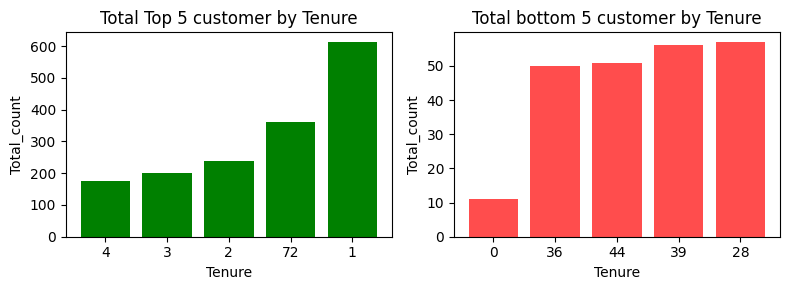

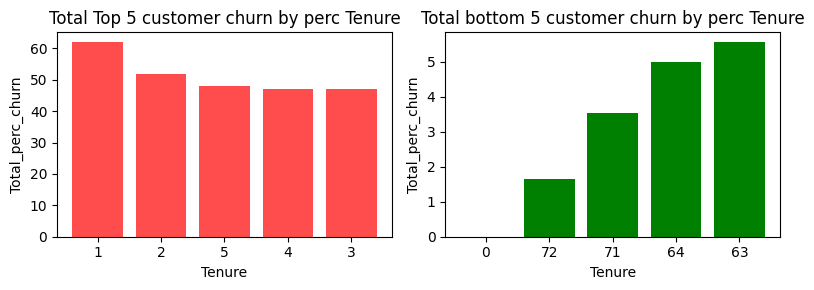

In [21]:
#visualise by graph
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.bar(top_5['tenure'].astype(str),top_5['total_count'],color='green')
plt.title('Total Top 5 customer by Tenure')
plt.xlabel('Tenure')
plt.ylabel('Total_count')

plt.subplot(1,2,2)
plt.bar(bottom_5['tenure'].astype(str),bottom_5['total_count'],color='#ff4d4d')
plt.title('Total bottom 5 customer by Tenure')
plt.xlabel('Tenure')
plt.ylabel('Total_count')

plt.tight_layout()
plt.show()

#visualise by graph
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.bar(highest_churn_perc[::-1].index.astype(str),highest_churn_perc[::-1]['perc_churn'],color='#ff4d4d')
plt.title('Total Top 5 customer churn by perc Tenure')
plt.xlabel('Tenure')
plt.ylabel('Total_perc_churn')

plt.subplot(1,2,2)
plt.bar(lowest_churn_perc.index.astype(str),lowest_churn_perc['perc_churn'],color='green')
plt.title('Total bottom 5 customer churn by perc Tenure')
plt.xlabel('Tenure')
plt.ylabel('Total_perc_churn')

plt.tight_layout()
plt.show()


##### Insight >>>

In [22]:
print("Insight :\n")
print('There is showing top 5 and bottom 5 customer by tenure in first chart')
print('There is showing top 5 and bottom 5 customer by percentage of churn in second chart')

Insight :

There is showing top 5 and bottom 5 customer by tenure in first chart
There is showing top 5 and bottom 5 customer by percentage of churn in second chart


#### 7) Analysis of the Effect of 'MonthlyCharges' and 'TotalCharges' on Customer Churn?
#### 8) Analysis of the Total Customer of 'MonthlyCharges' and 'TotalCharges' ?

In [23]:
#calculating total customer belong to range
for value,i in enumerate(['MonthlyCharges','TotalCharges']):
    print(f'for {i} :\n')
    table = pd.cut(df[i], bins=12).value_counts().sort_index().reset_index()
    table.columns = ['Charges_range', 'count']
    print(f'Data distributed by {i} and calculate total no of customer belong to that range :\n')
    print(table)

#calculating perc of churn by monthly and totalcharges subcategory
for i in ['MonthlyCharges','TotalCharges']:
    #create bins
    bins = pd.cut(df[i], bins=12)
    #create table
    table = df.groupby(bins)['Churn'].value_counts().unstack()
    table['perc_churn']=round((table['Yes']/(table['Yes']+table['No']))*100,2)
    print(f'\npercent of customer churn by {i} :')
    print(table.sort_values('perc_churn'))    

for MonthlyCharges :

Data distributed by MonthlyCharges and calculate total no of customer belong to that range :

        Charges_range  count
0     (18.15, 26.625]   1604
1      (26.625, 35.0]    131
2      (35.0, 43.375]    164
3     (43.375, 51.75]    552
4     (51.75, 60.125]    474
5      (60.125, 68.5]    351
6      (68.5, 76.875]    832
7     (76.875, 85.25]    782
8     (85.25, 93.625]    676
9     (93.625, 102.0]    752
10   (102.0, 110.375]    528
11  (110.375, 118.75]    197
for TotalCharges :

Data distributed by TotalCharges and calculate total no of customer belong to that range :

           Charges_range  count
0      (10.134, 740.967]   2466
1    (740.967, 1463.133]   1166
2     (1463.133, 2185.3]    684
3     (2185.3, 2907.467]    473
4   (2907.467, 3629.633]    415
5     (3629.633, 4351.8]    377
6     (4351.8, 5073.967]    368
7   (5073.967, 5796.133]    311
8     (5796.133, 6518.3]    291
9     (6518.3, 7240.467]    230
10  (7240.467, 7962.633]    174
11    (7962

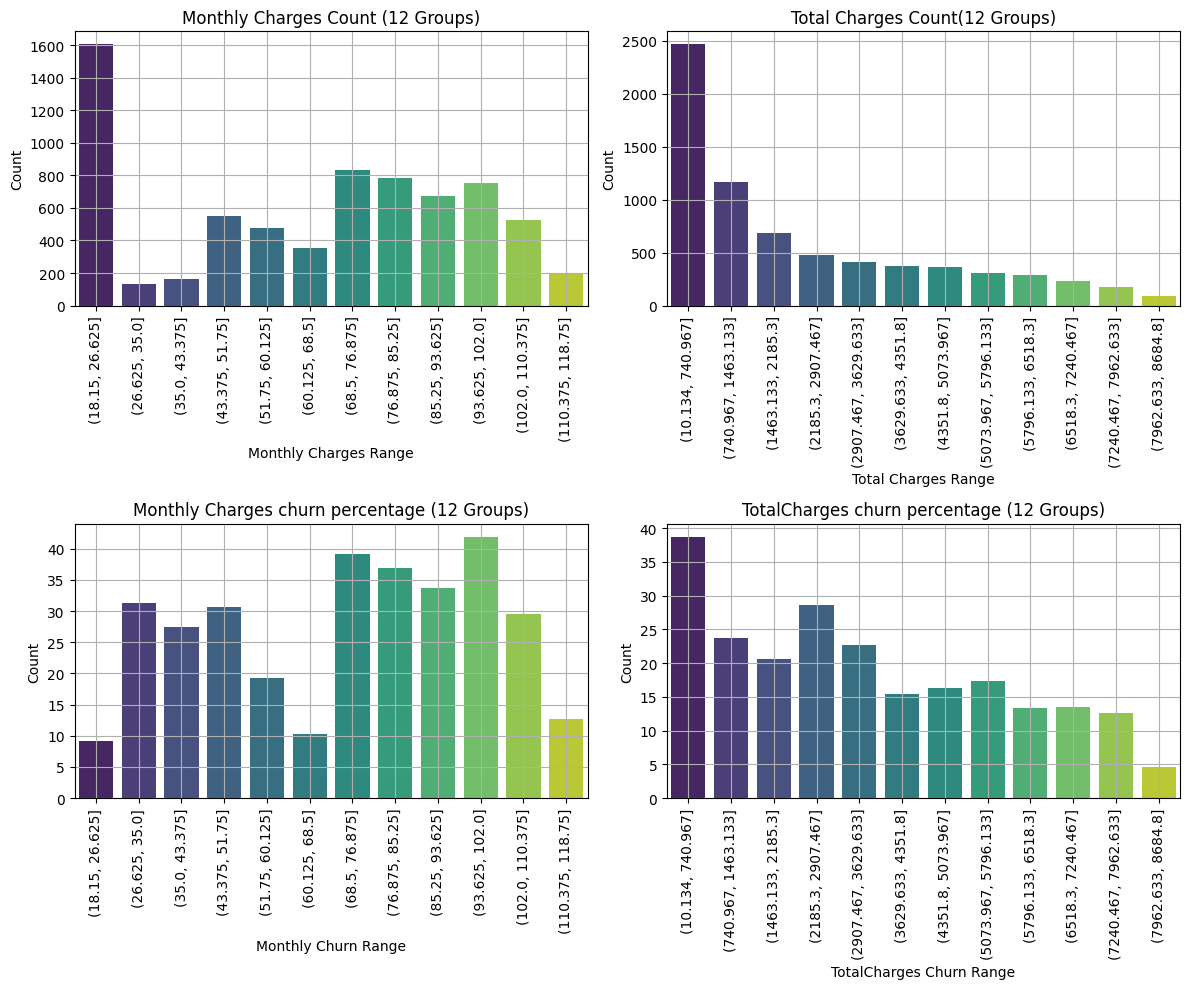

In [24]:
#visualise data 
plt.figure(figsize=(12,10))
plt.subplot(2,2,1)
table = pd.cut(df['MonthlyCharges'], bins=12).value_counts().reset_index().sort_values('count')
table.columns = ['MonthlyCharges_range', 'count']
sns.barplot(x=table['MonthlyCharges_range'], y=table['count'],palette='viridis')  #Seaborn barplot() does not automatically keep the order of your DataFrame rows.
plt.xlabel("Monthly Charges Range")
plt.ylabel("Count")
plt.title("Monthly Charges Count (12 Groups)")
plt.grid(True) 
plt.xticks(rotation=90)


plt.subplot(2,2,2)
table = pd.cut(df['TotalCharges'], bins=12).value_counts().sort_values().reset_index()
table.columns = ['TotalCharges_range', 'count']
sns.barplot(x=table['TotalCharges_range'], y=table['count'],palette='viridis')
plt.xlabel("Total Charges Range")
plt.ylabel("Count")
plt.title("Total Charges Count(12 Groups)")
plt.grid(True)
plt.xticks(rotation=90) 


#checking data by monthly and total charges by customer churn ratio

plt.subplot(2,2,3)
bins = pd.cut(df['MonthlyCharges'], bins=12)
table = df.groupby(bins)['Churn'].value_counts().unstack()
table['perc_churn']=round((table['Yes']/(table['Yes']+table['No']))*100,2)
table=table.sort_values('perc_churn')
table

sns.barplot(x=table.index, y=table.perc_churn,palette='viridis')  #Seaborn barplot() does not automatically keep the order of your DataFrame rows.
plt.xlabel("Monthly Churn Range")
plt.ylabel("Count")
plt.title("Monthly Charges churn percentage (12 Groups)")
plt.grid(True) 
plt.xticks(rotation=90)

plt.subplot(2,2,4)
bins = pd.cut(df['TotalCharges'], bins=12)
table = df.groupby(bins)['Churn'].value_counts().unstack()
table['perc_churn']=round((table['Yes']/(table['Yes']+table['No']))*100,2)
table=table.sort_values('perc_churn')

sns.barplot(x=table.index, y=table.perc_churn,palette='viridis')  #Seaborn barplot() does not automatically keep the order of your DataFrame rows.
plt.xlabel("TotalCharges Churn Range")
plt.ylabel("Count")
plt.title("TotalCharges churn percentage (12 Groups)")
plt.grid(True) 
plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

##### Insight>>>

In [25]:
print("Insight :\n")

print("MonthlyCharges 18.15-26.625 has highest no of customer and there is lowest percetage of customer churn\n")
print("TotalCharges 10.134-740.967 has highest no of customer and there is also highest percentage of customer churn ")


Insight :

MonthlyCharges 18.15-26.625 has highest no of customer and there is lowest percetage of customer churn

TotalCharges 10.134-740.967 has highest no of customer and there is also highest percentage of customer churn 


## Feature Engineering :

#### Adjust skewness by transformation:

variable TotalCherges has skewness : ,0.9633155974592842

   log_transform  sqrt_transform  power_transform
0      -0.752664        0.309874        -0.145072

Finally transform data by using power_transformer because of skew near to zero 


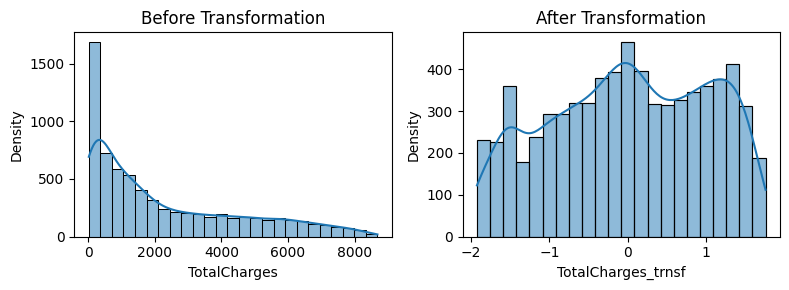

In [26]:
('mean > median ie TotalCharges data skewed toward right\n')
print(f"variable TotalCherges has skewness : ,{df['TotalCharges'].skew()}\n")

#transforming data to adjust skewness 

#log transformer
log_transform=np.log(df['TotalCharges']).skew()
#sqrt transformer
sqrt_transform=np.sqrt(df['TotalCharges']).skew() 
#power transformer
pt=PowerTransformer()
power_transform=pd.DataFrame(pt.fit_transform(df[['TotalCharges']])).skew()[0]

#create dataframe
a=pd.DataFrame({'log_transform':log_transform,
             'sqrt_transform':sqrt_transform,
             "power_transform":power_transform},index=[0])

print(a)

print('\nFinally transform data by using power_transformer because of skew near to zero ')

df['TotalCharges_trnsf']=pd.DataFrame(pt.fit_transform(df[['TotalCharges']]))       #note: not replacing higher (above95) percentile because all value are real here those customer is longer service taking then they paid more so

#draw data distribution diagram after replacing space by median value
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.title("Before Transformation")
sns.histplot(df['TotalCharges'], kde=True)
plt.xlabel('TotalCharges')
plt.ylabel('Density')
plt.subplot(1,2,2)
plt.title("After Transformation")
sns.histplot(df['TotalCharges_trnsf'],kde=True)
plt.xlabel('TotalCharges_trnsf')
plt.ylabel('Density')
plt.tight_layout() 
plt.show()

#drop main columns 
df.drop(columns='TotalCharges',inplace=True)
#rename of columns TotalCharges_trnsf to TotalCharges
df.rename(columns={'TotalCharges_trnsf':'TotalCharges'},inplace=True)

#### Scaling data :

In [27]:
#transforming data

minscale=MinMaxScaler()
df[['MonthlyCharges','tenure']] = minscale.fit_transform(df[['MonthlyCharges','tenure']])

In [28]:
df.head(1)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,TotalCharges
0,7590-VHVEG,Female,0,Yes,No,0.013889,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,0.115423,No,-1.805206


#### To transform categorical data (str) to int :

To transform categorical data (str) to int type there are too many method like 
* OneHotEncoding,
* LabelEncoding,
* Map method ,
* pd.get_dummies
  
but for practice i use all 

In [29]:
#map

#use map method to change 'yes'>1 and 'No'>0 'No internet service' >2
#2-category
df['Churn']=df['Churn'].map({'Yes':1,'No':0})
df['gender']=df['gender'].map({'Male':1,'Female':0})
df['Partner']=df['Partner'].map({'Yes':1,'No':0})
df['Dependents']=df['Dependents'].map({'Yes':1,'No':0})
#3-category
df['MultipleLines']=df['MultipleLines'].map({'Yes':1,'No':0,'No phone service':2})
df['TechSupport']=df['TechSupport'].map({'Yes':1,'No':0,'No internet service':2})
df['OnlineSecurity']=df['OnlineSecurity'].map({'Yes':1,'No':0,'No internet service':2})
df['OnlineBackup']=df['OnlineBackup'].map({'Yes':1,'No':0,'No internet service':2})
df['DeviceProtection']=df['DeviceProtection'].map({'Yes':1,'No':0,'No internet service':2})
df['StreamingTV']=df['StreamingTV'].map({'Yes':1,'No':0,'No internet service':2})
df['StreamingMovies']=df['StreamingMovies'].map({'Yes':1,'No':0,'No internet service':2})


#LabelEncoder 

le=LabelEncoder()
cols = ['PhoneService', 'PaperlessBilling']

for col in cols:
    df[col] = le.fit_transform(df[col])

#get dummies

a=pd.get_dummies(df['PaymentMethod'],dtype=int,prefix='PaymentMethod')
#added in main dataframe
df=pd.concat([df,a],axis=1)
df.drop(columns='PaymentMethod',inplace=True)    #droping main columns

#OneHotEncoder

oe=OneHotEncoder(sparse_output=False,feature_name_combiner='concat',dtype=int)
encoded= oe.fit_transform(df[['InternetService','Contract']])

df.drop(columns=['InternetService','Contract'],inplace=True)   #drop original

cols=oe.get_feature_names_out()
df=pd.concat([df,pd.DataFrame(encoded, columns=cols)],axis=1)


#### Checking correlation of variables :

Correlation Map :



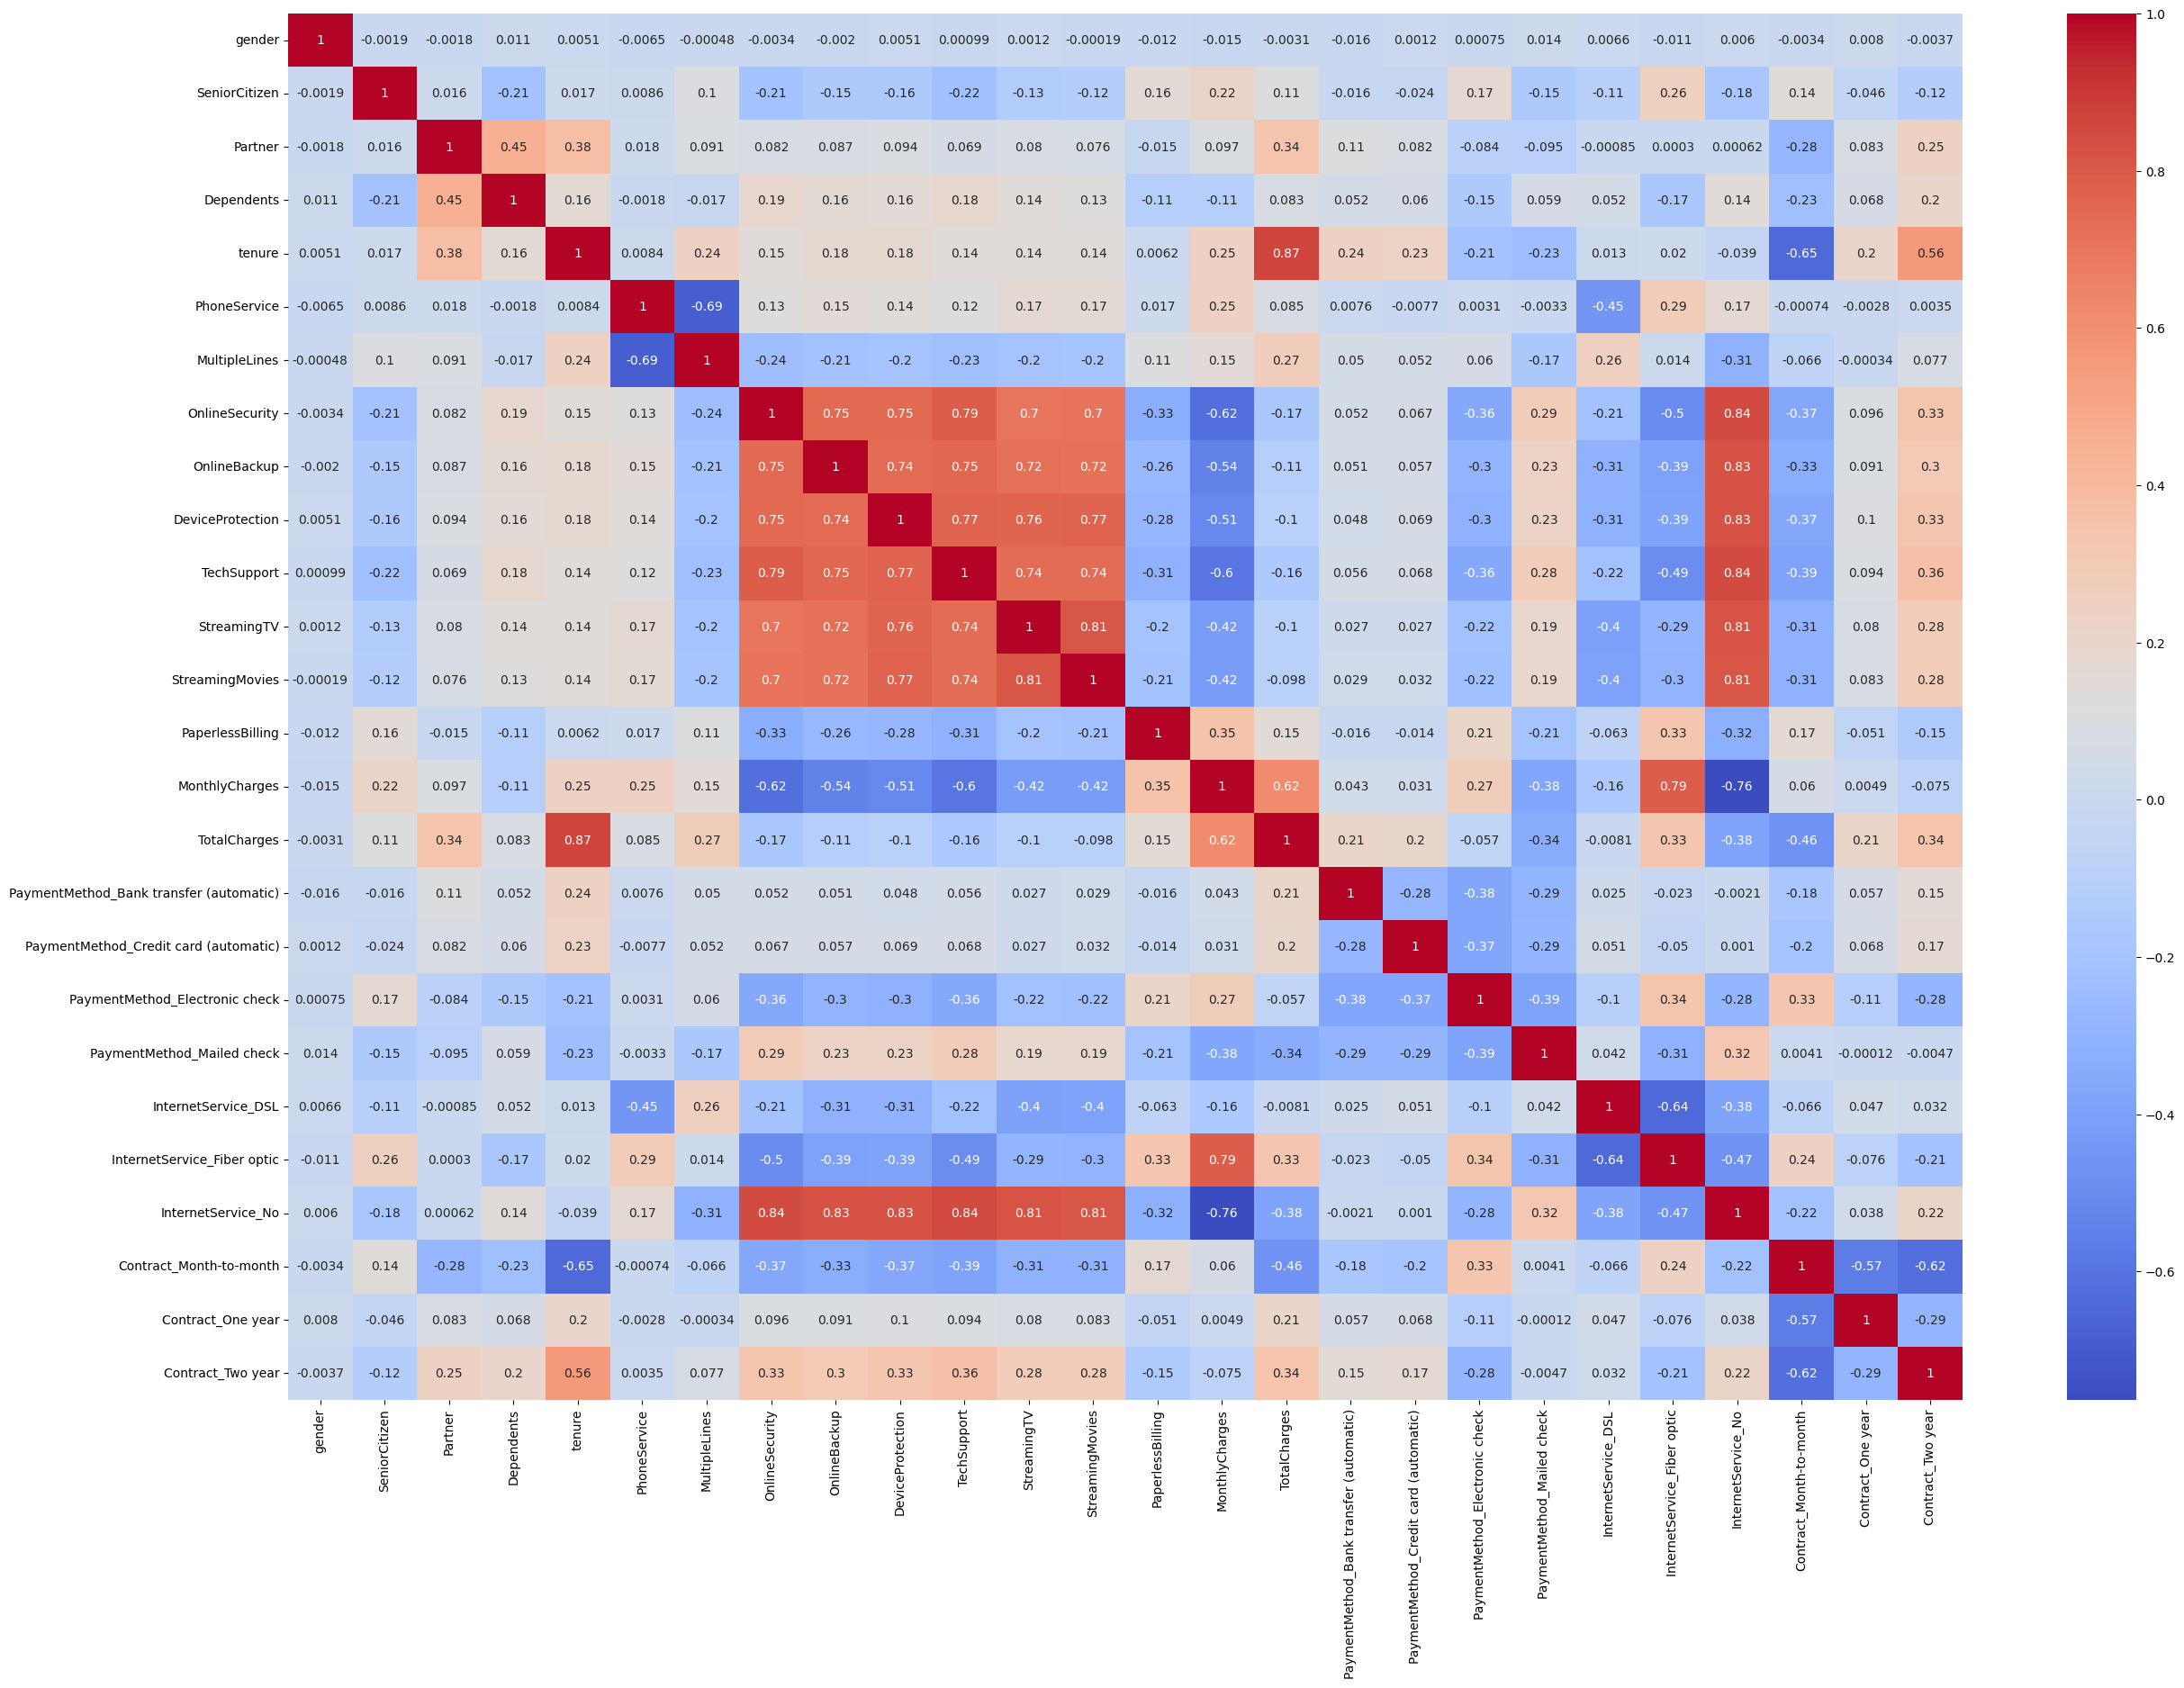

In [30]:
#checking correlation  of each features
print("Correlation Map :\n")
plt.figure(figsize=(30,20))
sns.heatmap(df.drop(['Churn','customerID'],axis=1).corr(),annot=True,cmap='coolwarm')
plt.show()


#### Feature Selection (by VIF method) : 

In [31]:

#create function to calculate vif
def calc_vif(X):
    """It calculate vif of input data"""
# Calculating VIF
    vif= pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return(vif)

"""VIF = 1 → no multicollinearity\
    VIF > 5 → moderate problem\
        VIF > 10 → serious multicollinearity"""


print(calc_vif(df[[i for i in df.describe().columns if i not in ['customerID','Churn','PaymentMethod_Bank transfer (automatic)',
                                                                 'InternetService_DSL','InternetService_No', 'Contract_Month-to-month',
                                                               'PhoneService' ]]]))


                                variables        VIF
0                                  gender   1.991169
1                           SeniorCitizen   1.372278
2                                 Partner   2.822217
3                              Dependents   1.966014
4                                  tenure  16.103135
5                           MultipleLines   2.199098
6                          OnlineSecurity   6.929056
7                            OnlineBackup   6.568402
8                        DeviceProtection   7.395705
9                             TechSupport   7.631604
10                            StreamingTV   8.024718
11                        StreamingMovies   8.085513
12                       PaperlessBilling   2.916207
13                         MonthlyCharges  12.451085
14                           TotalCharges   4.999658
15  PaymentMethod_Credit card (automatic)   1.921171
16         PaymentMethod_Electronic check   2.852320
17             PaymentMethod_Mailed check   2.

#### New feature creating:

In [32]:
def cal_MonthlyCharges(X):
    "This function return category of MonthlyCharges"
    if X<=30:
        return 0
    elif X>30 and X<=60:
        return 1
    elif X>60 and X<=90:
        return 2
    else:
        return 3

df['MonthlyCharges_category']=df['MonthlyCharges'].apply(cal_MonthlyCharges)

## ML model Fittings

### Dividing data train and test :

In [33]:
#Dividing data in dependent (y) and Independent variable (X)
X = df.drop(['Churn','customerID'],axis=1)
y = df['Churn']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=5295,stratify=y)

### Data Class Balancing (SMOTE) :   To prevent data leakage so apply on train data

In [34]:
# count diff class total 
print("Checking data distributed with different classes :")
print(y_train.value_counts().reset_index())
print("\nData is imbalanced here so use SMOTE technique to balance data :\n")

print(f"Before smote technique shape of real data is : {X_train.shape}")
#creating 1 category data to 3000 time total
smote = SMOTE(sampling_strategy={1:3000}, random_state=5)  #partial oversampling data 

X_train, y_train = smote.fit_resample(X_train, y_train)

print(f"After smote technique shape of resampled data is : {X_train.shape}")
print("and data distribution with diff class: ",y_train.value_counts())

Checking data distributed with different classes :
   Churn  count
0      0   4139
1      1   1495

Data is imbalanced here so use SMOTE technique to balance data :

Before smote technique shape of real data is : (5634, 27)
After smote technique shape of resampled data is : (7139, 27)
and data distribution with diff class:  Churn
0    4139
1    3000
Name: count, dtype: int64


### model1-Logistic Classification :

In [35]:
different_model_performance={}

In [36]:
#logistic regression for classification models
model1=LogisticRegression(fit_intercept=True, max_iter=10000)

#fitting on train data 
model1.fit(X_train,y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### metrics (model performance): 

In [37]:
#prediction of model on train data and test data
y_train_pr=model1.predict(X_train)
y_test_pr=model1.predict(X_test)

#on train data
print('Accuracy of model on  train data :',accuracy_score(y_train,y_train_pr))    #accuracy=(tp+tn)/(tp+tn+fp+fn)
print('Precison of model on train data :',precision_score(y_train,y_train_pr))     #precision=tp/(tp+fp)
print('Recall of model on train data :',recall_score(y_train,y_train_pr))          #recall=tp/(tp+fn)

#on test data
print('Accuracy of model on  test data :',accuracy_score(y_test,y_test_pr))
print('Precison of model on test data :',precision_score(y_test,y_test_pr)) 
print('Recall of model on test data :',recall_score(y_test,y_test_pr))          

Accuracy of model on  train data : 0.8075360694775179
Precison of model on train data : 0.7674342105263158
Recall of model on train data : 0.7776666666666666
Accuracy of model on  test data : 0.7622427253371186
Precison of model on test data : 0.5419354838709678
Recall of model on test data : 0.6737967914438503


In [38]:
#adding performance data into 'different_model_performance' dictionary to compare diff model
different_model_performance['model1']={'train_accuracy':accuracy_score(y_train,y_train_pr),'train_precision':precision_score(y_train,y_train_pr),'train_recall':recall_score(y_train,y_train_pr),
'test_accuracy':accuracy_score(y_test,y_test_pr),'test_precision':precision_score(y_test,y_test_pr),'test_recall':recall_score(y_test,y_test_pr)}

### model2- DecisionTree (method-Information gain,gini,chi2) :

In [39]:
#model creation
model2=DecisionTreeClassifier(criterion='gini', max_leaf_nodes=20, random_state=0)   #if criterion=entropy >>>informationgain method 
model2.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",20
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

#### metrics (model performance): 

In [40]:
#prediction of model on train data and test data
y_train_pr=model2.predict(X_train)
y_test_pr=model2.predict(X_test)

#on train data
print('Accuracy of model on  train data :',accuracy_score(y_train,y_train_pr))    #accuracy=(tp+tn)/(tp+tn+fp+fn)
print('Precison of model on train data :',precision_score(y_train,y_train_pr))     #precision=tp/(tp+fp)
print('Recall of model on train data :',recall_score(y_train,y_train_pr))          #recall=tp/(tp+fn)

#on test data
print('Accuracy of model on  test data :',accuracy_score(y_test,y_test_pr))
print('Precison of model on test data :',precision_score(y_test,y_test_pr)) 
print('Recall of model on test data :',recall_score(y_test,y_test_pr))       

Accuracy of model on  train data : 0.7879254797590699
Precison of model on train data : 0.7410772225827384
Recall of model on train data : 0.7613333333333333
Accuracy of model on  test data : 0.758694109297374
Precison of model on test data : 0.5348360655737705
Recall of model on test data : 0.6978609625668449


In [41]:
#adding performance data into 'different_model_performance' dictionary to compare diff model
different_model_performance['model2']={'train_accuracy':accuracy_score(y_train,y_train_pr),'train_precision':precision_score(y_train,y_train_pr),'train_recall':recall_score(y_train,y_train_pr),
'test_accuracy':accuracy_score(y_test,y_test_pr),'test_precision':precision_score(y_test,y_test_pr),'test_recall':recall_score(y_test,y_test_pr)}

#### Visualisation of tree :

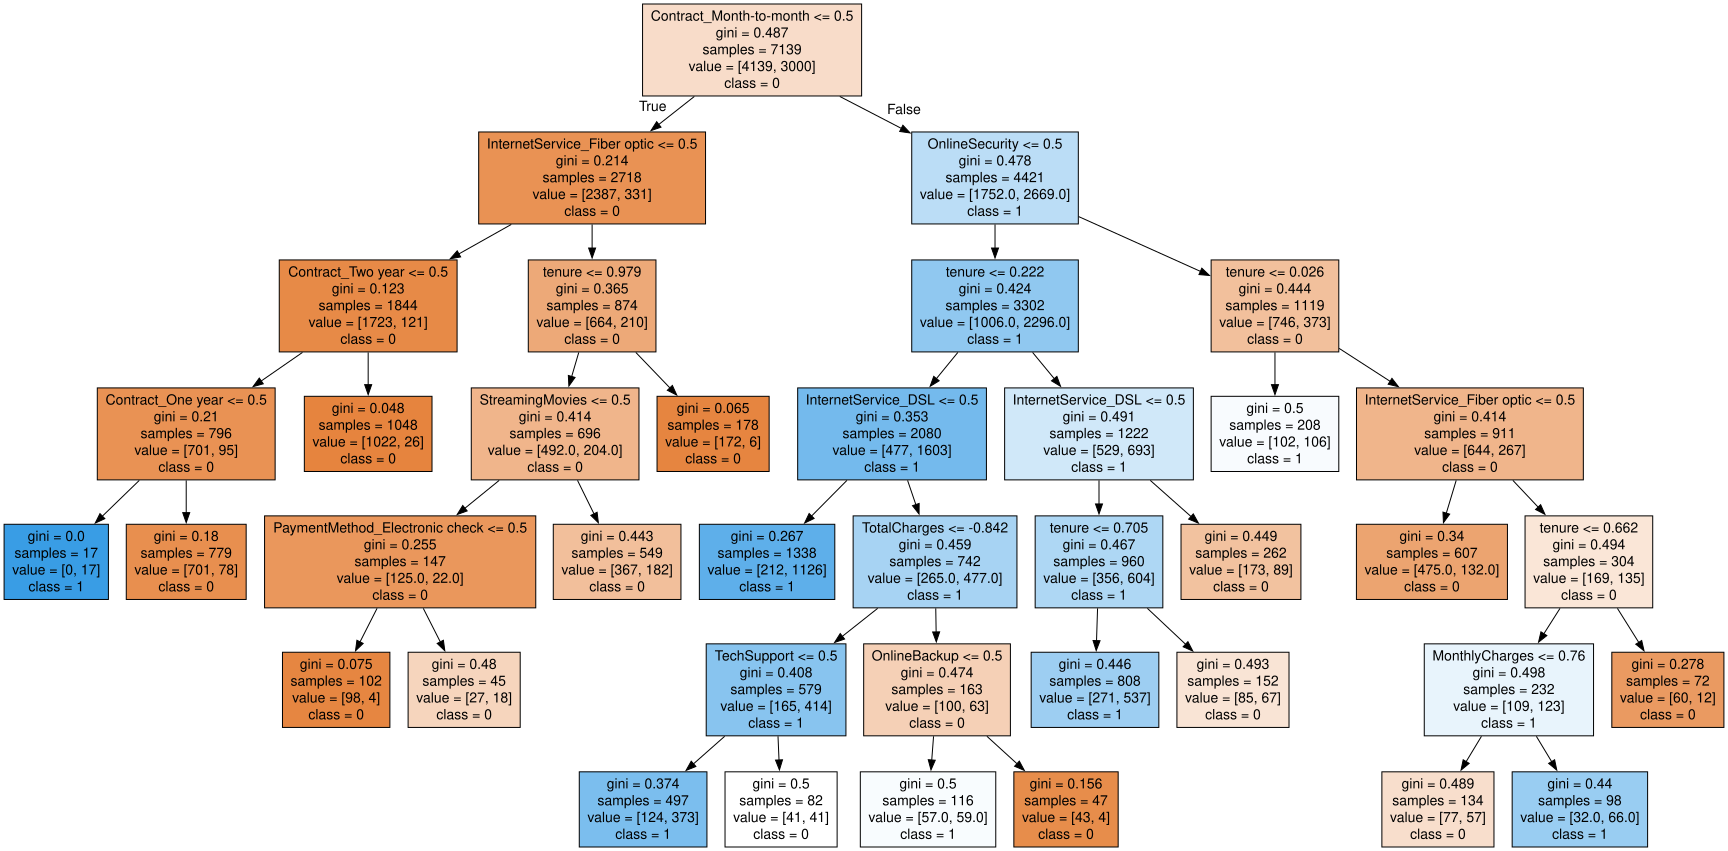

In [42]:
#to see tree 
# Export the decision tree to graphviz format
graph = Source(tree.export_graphviz(model2, out_file=None
   , feature_names=X_train.columns, class_names=['0', '1']
   , filled = True))

# Display the decision tree using SVG format
display(SVG(graph.pipe(format='svg')))

### model3-RandomForestClassifier  (Bagging method):

In [43]:
#model creation on RandomForestClassifier 
model3=RandomForestClassifier(n_estimators=100,max_depth=15,random_state=5295)      #bagging ensemble method
model3.fit(X_train,y_train)

#prediction of model on train data and test data
y_train_pr=model3.predict(X_train)
y_test_pr=model3.predict(X_test)

#on train data
print('Accuracy of model on  train data :',accuracy_score(y_train,y_train_pr))    #accuracy=(tp+tn)/(tp+tn+fp+fn)
print('Precison of model on train data :',precision_score(y_train,y_train_pr))     #precision=tp/(tp+fp)
print('Recall of model on train data :',recall_score(y_train,y_train_pr))          #recall=tp/(tp+fn)

#on test data
print('Accuracy of model on  test data :',accuracy_score(y_test,y_test_pr))
print('Precison of model on test data :',precision_score(y_test,y_test_pr)) 
print('Recall of model on test data :',recall_score(y_test,y_test_pr))    

Accuracy of model on  train data : 0.9752066115702479
Precison of model on train data : 0.9468186134852802
Recall of model on train data : 0.997
Accuracy of model on  test data : 0.7622427253371186
Precison of model on test data : 0.5434298440979956
Recall of model on test data : 0.6524064171122995


In [44]:
print('Above models is overfitted so trying gridsearchcv to find best parameters')
# Hyperparameter tuning

#classifier = RandomForestClassifier() # For GBM, use GradientBoostingClassifier()
model3 = RandomForestClassifier()
grid_values = {'n_estimators':[ 80,  100,150], 'max_depth':[ 3,5,7]}
model3_grid = GridSearchCV(model3, param_grid = grid_values, scoring = 'roc_auc', cv=5)     
RandomForestClassifier
# Fit the object to train dataset
model3_grid.fit(X_train, y_train)

print(model3_grid.best_params_) 

#prediction of model on train data and test data
y_train_pr=model3_grid.predict(X_train)
y_test_pr=model3_grid.predict(X_test)

#on train data
print('Accuracy of model on  train data :',accuracy_score(y_train,y_train_pr))    #accuracy=(tp+tn)/(tp+tn+fp+fn)
print('Precison of model on train data :',precision_score(y_train,y_train_pr))     #precision=tp/(tp+fp)
print('Recall of model on train data :',recall_score(y_train,y_train_pr))          #recall=tp/(tp+fn)

#on test data
print('Accuracy of model on  test data :',accuracy_score(y_test,y_test_pr))
print('Precison of model on test data :',precision_score(y_test,y_test_pr)) 
print('Recall of model on test data :',recall_score(y_test,y_test_pr)) 

#selecting best parameters 


Above models is overfitted so trying gridsearchcv to find best parameters
{'max_depth': 7, 'n_estimators': 100}
Accuracy of model on  train data : 0.8114581874212075
Precison of model on train data : 0.7666021921341071
Recall of model on train data : 0.7926666666666666
Accuracy of model on  test data : 0.7551454932576295
Precison of model on test data : 0.5287128712871287
Recall of model on test data : 0.713903743315508


In [45]:
#adding performance data into 'different_model_performance' dictionary to compare diff model
different_model_performance['model3_grid']={'train_accuracy':accuracy_score(y_train,y_train_pr),'train_precision':precision_score(y_train,y_train_pr),'train_recall':recall_score(y_train,y_train_pr),
'test_accuracy':accuracy_score(y_test,y_test_pr),'test_precision':precision_score(y_test,y_test_pr),'test_recall':recall_score(y_test,y_test_pr)}

#### Top 10 features contribute more :

In [46]:
#checking importance of feature for models
best = model3_grid.best_estimator_
importance = best.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})

#checking percentage wise 

feature_importance['Contribution %'] = (
    feature_importance['Importance'] /
    feature_importance['Importance'].sum()
) * 100

print('Top 10 feature contribute to predict category :\n')
feature_importance.sort_values('Contribution %',ascending=False).head(10)

Top 10 feature contribute to predict category :



,Feature,Importance,Contribution %
23,Contract_Month-to-month,0.160647,16.064691
7,OnlineSecurity,0.125495,12.549496
4,tenure,0.111928,11.192750
10,TechSupport,0.089045,8.904503
15,TotalCharges,0.080010,8.001044
25,Contract_Two year,0.071891,7.189114
14,MonthlyCharges,0.053395,5.339535
8,OnlineBackup,0.052695,5.269541
21,InternetService_Fiber optic,0.051375,5.137465
24,Contract_One year,0.030501,3.050107


#### Model Explainability LIME/ELI5/SHAP:

1)LIME: Local Interpretable Model-Agnostic Explanations

In [47]:
#create function for lime models
def checking_feature_contribution_lime(model,X_train,X_test,observation_1=1): 
    """This model run on random forest classifier and return which top 5 feature contribute to predict category"""
    
    import lime
    from lime.lime_tabular import LimeTabularExplainer
    
    predict_fn_rf = lambda x: model.predict_proba(x).astype(float)
    
    # Create the LIME Explainer
    explainer = LimeTabularExplainer(X_train.values ,feature_names = X_train.columns, kernel_width=2) 
    
   
    exp = explainer.explain_instance(X_test.values[observation_1], predict_fn_rf, num_features=7)     #,top_labels=(2) help to categorised feature contribution
    #exp.show_in_notebook(show_all=False)
    
    
    from IPython.display import display,HTML
    return display(HTML(exp.as_html()))

In [48]:
print("y_test :",y_test.iloc[0])
print("y_test_pr :",y_test_pr[0])

checking_feature_contribution_lime(model3_grid,X_train,X_test,0)  


y_test : 1
y_test_pr : 1


#### Insight >>>

These feature contributes to predict class 1
Contract_Two year	0.00
OnlineSecurity	0.00
tenure	0.01
TechSupport	0.00
Contract_Month-to-month	1.00
InternetService_DSL	0.00
Contract_One year	0.00
TotalCharges	-1.49
InternetService_Fiber optic	1.00
OnlineBackup	0.0


##### SHAP :

In [49]:
def checking_feature_contribution_shap(model,X_test,observation=1):
    """it return shap value and which feature contribute how much percentage"""
    import shap
    shap.initjs()
    explainer = shap.TreeExplainer(model.best_estimator_)
    X_sample = X_test.iloc[[observation]]
    # predict class
    pred_class = model.best_estimator_.predict(X_sample)[0]
    # compute shap values
    shap_values = explainer.shap_values(X_sample)
    # force plot for predicted class
    return shap.force_plot(
        explainer.expected_value[pred_class],
        shap_values[0][:, pred_class],
        X_sample.iloc[0],
        out_names=f"Predicted class: {pred_class}"
    )

In [50]:
checking_feature_contribution_shap(model3_grid,X_test,2)

#### Insight >>>

These features increase the probability of the predicted class 
OnlineBackup = 2
InternetService_Fiber optic = 0
TechSupport = 2
Contract_Two year = 1
OnlineSecurity = 2



### model4) GradientBoostingClassifier or Xgboost (ensemble boosting) :

In [51]:
#model creation on RandomForestClassifier 
model4=GradientBoostingClassifier(n_estimators=100,max_depth=5,random_state=5295)      #boosting ensemble method
model4.fit(X_train,y_train)

#prediction of model on train data and test data
y_train_pr=model4.predict(X_train)
y_test_pr=model4.predict(X_test)

#on train data
print('Accuracy of model on  train data :',accuracy_score(y_train,y_train_pr))    #accuracy=(tp+tn)/(tp+tn+fp+fn)
print('Precison of model on train data :',precision_score(y_train,y_train_pr))     #precision=tp/(tp+fp)
print('Recall of model on train data :',recall_score(y_train,y_train_pr))          #recall=tp/(tp+fn)

#on test data
print('Accuracy of model on  test data :',accuracy_score(y_test,y_test_pr))
print('Precison of model on test data :',precision_score(y_test,y_test_pr)) 
print('Recall of model on test data :',recall_score(y_test,y_test_pr))    

Accuracy of model on  train data : 0.8761731334920857
Precison of model on train data : 0.8412903225806452
Recall of model on train data : 0.8693333333333333
Accuracy of model on  test data : 0.7629524485450674
Precison of model on test data : 0.5452488687782805
Recall of model on test data : 0.6443850267379679


In [52]:
print('Above models is overfitted so trying gridsearchcv to find best parameters')
# Hyperparameter tuning

#classifier = RandomForestClassifier() # For GBM, use GradientBoostingClassifier()
model4 = GradientBoostingClassifier()
grid_values = {'n_estimators':[ 80,  100,150], 'max_depth':[ 3,5],'max_leaf_nodes':[3,5]}
model4_grid = GridSearchCV(model4, param_grid = grid_values, scoring = 'roc_auc', cv=3)     
RandomForestClassifier
# Fit the object to train dataset
model4_grid.fit(X_train, y_train)

print(model4_grid.best_params_) 

#prediction of model on train data and test data
y_train_pr=model4_grid.predict(X_train)
y_test_pr=model4_grid.predict(X_test)

#on train data
print('Accuracy of model on  train data :',accuracy_score(y_train,y_train_pr))    #accuracy=(tp+tn)/(tp+tn+fp+fn)
print('Precison of model on train data :',precision_score(y_train,y_train_pr))     #precision=tp/(tp+fp)
print('Recall of model on train data :',recall_score(y_train,y_train_pr))          #recall=tp/(tp+fn)

#on test data
print('Accuracy of model on  test data :',accuracy_score(y_test,y_test_pr))
print('Precison of model on test data :',precision_score(y_test,y_test_pr)) 
print('Recall of model on test data :',recall_score(y_test,y_test_pr)) 

#selecting best parameters 

Above models is overfitted so trying gridsearchcv to find best parameters
{'max_depth': 5, 'max_leaf_nodes': 5, 'n_estimators': 150}
Accuracy of model on  train data : 0.8166409861325116
Precison of model on train data : 0.7789508413064995
Recall of model on train data : 0.787
Accuracy of model on  test data : 0.7693399574166075
Precison of model on test data : 0.5529157667386609
Recall of model on test data : 0.6844919786096256


In [53]:
#adding performance data into 'different_model_performance' dictionary to compare diff model
different_model_performance['model4_grid']={'train_accuracy':accuracy_score(y_train,y_train_pr),'train_precision':precision_score(y_train,y_train_pr),'train_recall':recall_score(y_train,y_train_pr),
'test_accuracy':accuracy_score(y_test,y_test_pr),'test_precision':precision_score(y_test,y_test_pr),'test_recall':recall_score(y_test,y_test_pr)}

#### Top 10 Feature contribution :

In [54]:
#checking importance of feature for models
best_rf = model4_grid.best_estimator_
importance = best_rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})

#checking percentage wise 

feature_importance['Contribution %'] = (
    feature_importance['Importance'] /
    feature_importance['Importance'].sum()
) * 100

print('Top 10 feature contribute to predict category :\n')
feature_importance.sort_values('Contribution %',ascending=False).head(10)

Top 10 feature contribute to predict category :



,Feature,Importance,Contribution %
23,Contract_Month-to-month,0.336725,33.672538
7,OnlineSecurity,0.168518,16.851751
4,tenure,0.133392,13.339189
10,TechSupport,0.086516,8.651558
14,MonthlyCharges,0.063049,6.304864
20,InternetService_DSL,0.032809,3.280909
15,TotalCharges,0.028065,2.806451
25,Contract_Two year,0.025427,2.542749
18,PaymentMethod_Electronic check,0.025335,2.533535
8,OnlineBackup,0.024790,2.479044


#### Model Explainability (LIME/SHAP):

In [55]:
#use lime function to check top feature 

checking_feature_contribution_lime(model4_grid,X_train,X_test,2)

In [56]:
def checking_feature_contribution_shap(model, X_test, observation=1):
    """Return SHAP force plot for feature contribution"""
    
    import shap
    shap.initjs()
    
    explainer = shap.TreeExplainer(model.best_estimator_)
    
    X_sample = X_test.iloc[[observation]]
    
    # predict class
    pred_class = model.best_estimator_.predict(X_sample)[0]
    
    # compute shap values
    shap_values = explainer.shap_values(X_sample)
    
    # handle binary vs multiclass
    if isinstance(shap_values, list):  # multiclass
        values = shap_values[pred_class][0]
        expected = explainer.expected_value[pred_class]
    else:  # binary or regression
        values = shap_values[0]
        expected = explainer.expected_value
    
    return shap.force_plot(
        expected,
        values,
        X_sample.iloc[0],
        out_names=f"Predicted class: {pred_class}"
    )

In [57]:
print(y_test.iloc[2])
print(y_test_pr[2])
checking_feature_contribution_shap(model4_grid,X_test,observation=2)

0
0


#### Insight >>>

The above blue and red colour feature contribute tp predict class 0

### model 5) StackingClassifier :

In [58]:
# Base learners (tree-based)
base_learners = [
    ('dt', DecisionTreeClassifier(criterion='gini', max_leaf_nodes=6,  random_state=5295)),
    ('rf', RandomForestClassifier(max_depth= 4, n_estimators= 100, random_state=5295)),
    ('gb', GradientBoostingClassifier(max_depth= 4, max_leaf_nodes=5, n_estimators= 100,random_state=5295)),
    ('xb',XGBClassifier(max_depth= 3, max_leaf_nodes=2, n_estimators= 100,random_state=5295))
]

# Meta learner
meta_learner = LogisticRegression(fit_intercept=True, max_iter=100)

# Create stacking classifier
from sklearn.ensemble import StackingClassifier
model5 = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5
)

#model Fitting
model5.fit(X_train,y_train)

#prediction of model on train data and test data
y_train_pr=model5.predict(X_train)
y_test_pr=model5.predict(X_test)

#on train data
print('Accuracy of model on  train data :',accuracy_score(y_train,y_train_pr))    #accuracy=(tp+tn)/(tp+tn+fp+fn)
print('Precison of model on train data :',precision_score(y_train,y_train_pr))     #precision=tp/(tp+fp)
print('Recall of model on train data :',recall_score(y_train,y_train_pr))          #recall=tp/(tp+fn)

#on test data
print('Accuracy of model on  test data :',accuracy_score(y_test,y_test_pr))
print('Precison of model on test data :',precision_score(y_test,y_test_pr)) 
print('Recall of model on test data :',recall_score(y_test,y_test_pr))


Accuracy of model on  train data : 0.8303683989354251
Precison of model on train data : 0.7875281260045002
Recall of model on train data : 0.8166666666666667
Accuracy of model on  test data : 0.7608232789212207
Precison of model on test data : 0.5397849462365591
Recall of model on test data : 0.6711229946524064


In [59]:
#adding performance data into 'different_model_performance' dictionary to compare diff model
different_model_performance['model5']={'train_accuracy':accuracy_score(y_train,y_train_pr),'train_precision':precision_score(y_train,y_train_pr),'train_recall':recall_score(y_train,y_train_pr),
'test_accuracy':accuracy_score(y_test,y_test_pr),'test_precision':precision_score(y_test,y_test_pr),'test_recall':recall_score(y_test,y_test_pr)}

### model6-K-Nearest Neighbors

In [60]:
# Import KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier

#Setup arrays to store training and test accuracies
neighbors = np.arange(1,50)
train_accuracy =np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

for i,k in enumerate(neighbors):
    # Setup a knn classifier with k neighbors
    knn = KNeighborsClassifier(n_neighbors=k)

    # Fit the model
    knn.fit(X_train, y_train)

    # Compute accuracy on the training set
    train_accuracy[i] = knn.score(X_train, y_train)

    # Compute accuracy on the test set
    test_accuracy[i] = knn.score(X_test, y_test)

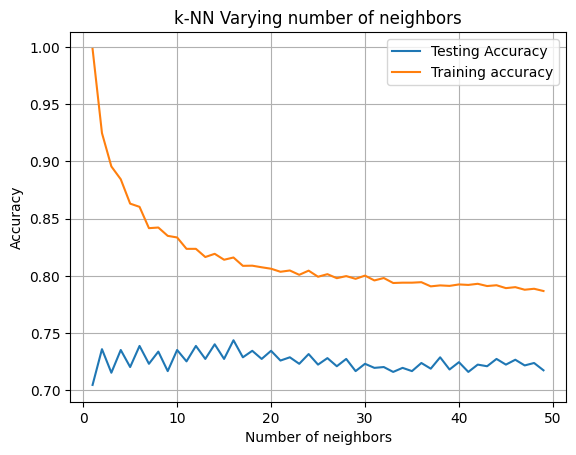

In [61]:
plt.title('k-NN Varying number of neighbors')
plt.plot(neighbors, test_accuracy, label='Testing Accuracy')
plt.plot(neighbors, train_accuracy, label='Training accuracy')
plt.legend()
plt.xlabel('Number of neighbors')
plt.ylabel('Accuracy')
plt.grid()
plt.show()

In [62]:
# Setup a knn classifier with k neighbors
model6 = KNeighborsClassifier(n_neighbors=16)

# Fit the model
model6.fit(X_train,y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",16
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### metrics :

In [63]:
#prediction of model on train data and test data
y_train_pr=model6.predict(X_train)
y_test_pr=model6.predict(X_test)

#on train data
print('Accuracy of model on  train data :',accuracy_score(y_train,y_train_pr))    #accuracy=(tp+tn)/(tp+tn+fp+fn)
print('Precison of model on train data :',precision_score(y_train,y_train_pr))     #precision=tp/(tp+fp)
print('Recall of model on train data :',recall_score(y_train,y_train_pr))          #recall=tp/(tp+fn)

#on test data
print('Accuracy of model on  test data :',accuracy_score(y_test,y_test_pr))
print('Precison of model on test data :',precision_score(y_test,y_test_pr)) 
print('Recall of model on test data :',recall_score(y_test,y_test_pr))
print('confusion metrics :\n' ,confusion_matrix(y_test,y_test_pr))

Accuracy of model on  train data : 0.8160806835691273
Precison of model on train data : 0.7553739025128671
Recall of model on train data : 0.8316666666666667
Accuracy of model on  test data : 0.7437899219304471
Precison of model on test data : 0.5123809523809524
Recall of model on test data : 0.7192513368983957
confusion metrics :
 [[779 256]
 [105 269]]


In [64]:
#adding performance data into 'different_model_performance' dictionary to compare diff model
different_model_performance['model6']={'train_accuracy':accuracy_score(y_train,y_train_pr),'train_precision':precision_score(y_train,y_train_pr),'train_recall':recall_score(y_train,y_train_pr),
'test_accuracy':accuracy_score(y_test,y_test_pr),'test_precision':precision_score(y_test,y_test_pr),'test_recall':recall_score(y_test,y_test_pr)}

###  model7-Naive Bayes Classifier :

In [65]:
#importing models 
from sklearn.naive_bayes import GaussianNB

model7=GaussianNB()
model7.fit(X_train,y_train)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [66]:
#prediction of model on train data and test data
y_train_pr=model7.predict(X_train)
y_test_pr=model7.predict(X_test)

#on train data
print('Accuracy of model on  train data :',accuracy_score(y_train,y_train_pr))    #accuracy=(tp+tn)/(tp+tn+fp+fn)
print('Precison of model on train data :',precision_score(y_train,y_train_pr))     #precision=tp/(tp+fp)
print('Recall of model on train data :',recall_score(y_train,y_train_pr))          #recall=tp/(tp+fn)

#on test data
print('Accuracy of model on  test data :',accuracy_score(y_test,y_test_pr))
print('Precison of model on test data :',precision_score(y_test,y_test_pr)) 
print('Recall of model on test data :',recall_score(y_test,y_test_pr))
print('confusion metrics :\n' ,confusion_matrix(y_test,y_test_pr))

Accuracy of model on  train data : 0.7498249054489424
Precison of model on train data : 0.6561213991769548
Recall of model on train data : 0.8503333333333334
Accuracy of model on  test data : 0.6777856635911994
Precison of model on test data : 0.4410029498525074
Recall of model on test data : 0.7994652406417112
confusion metrics :
 [[656 379]
 [ 75 299]]


In [67]:
#adding performance data into 'different_model_performance' dictionary to compare diff model
different_model_performance['model7']={'train_accuracy':accuracy_score(y_train,y_train_pr),'train_precision':precision_score(y_train,y_train_pr),'train_recall':recall_score(y_train,y_train_pr),
'test_accuracy':accuracy_score(y_test,y_test_pr),'test_precision':precision_score(y_test,y_test_pr),'test_recall':recall_score(y_test,y_test_pr)}

### Comparing Model performance :

In [68]:
pd.DataFrame(different_model_performance).T

,train_accuracy,train_precision,train_recall,test_accuracy,test_precision,test_recall
model1,0.807536,0.767434,0.777667,0.762243,0.541935,0.673797
model2,0.787925,0.741077,0.761333,0.758694,0.534836,0.697861
model3_grid,0.811458,0.766602,0.792667,0.755145,0.528713,0.713904
model4_grid,0.816641,0.778951,0.787000,0.769340,0.552916,0.684492
model5,0.830368,0.787528,0.816667,0.760823,0.539785,0.671123
model6,0.816081,0.755374,0.831667,0.743790,0.512381,0.719251
model7,0.749825,0.656121,0.850333,0.677786,0.441003,0.799465


###  Selecting model3_grid as final prediction models

### Creating ml pipeline to avoid any future mistake during preprocessing data 

#### 1)Splite data :

In [69]:
# final model creation for ml pipelines
df=pd.read_csv("../datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv")
#divide data into x and y
X = df.drop('Churn', axis=1)
y = df['Churn']
y=y.map({'No':0,'Yes':1})
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=5295,
    stratify=y
)

In [70]:
X.head(1)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85


#### 2) Create Custom Transformer (Feature Engineering)

In [71]:
#Step 1 — Create Custom Transformer (Feature Engineering)

class FeatureEngineering(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        X = X.copy()
        
        X = X.drop(columns=['customerID'])
        # convert TotalCharges
        X['TotalCharges'] = pd.to_numeric(X['TotalCharges'], errors='coerce')
        X['TotalCharges'] = X['TotalCharges'].fillna(X['MonthlyCharges'])

        # MonthlyCharges category
        def cal_MonthlyCharges(val):

            if val <= 30:
                return 0
            elif val <= 60:
                return 1
            elif val <= 90:
                return 2
            else:
                return 3

         # binary mapping
        binary_map = {'Yes':1,'No':0}

        for col in ['Partner','Dependents']:
            X[col] = X[col].map(binary_map)

        X['gender'] = X['gender'].map({'Male':1,'Female':0})

        # 3-category mapping
        X['MultipleLines'] = X['MultipleLines'].map({'Yes':1,'No':0,'No phone service':2})
        X['TechSupport'] = X['TechSupport'].map({'Yes':1,'No':0,'No internet service':2})
        X['OnlineSecurity'] = X['OnlineSecurity'].map({'Yes':1,'No':0,'No internet service':2})
        X['OnlineBackup'] = X['OnlineBackup'].map({'Yes':1,'No':0,'No internet service':2})
        X['DeviceProtection'] = X['DeviceProtection'].map({'Yes':1,'No':0,'No internet service':2})
        X['StreamingTV'] = X['StreamingTV'].map({'Yes':1,'No':0,'No internet service':2})
        X['StreamingMovies'] = X['StreamingMovies'].map({'Yes':1,'No':0,'No internet service':2})


        X['MonthlyCharges_category'] = X['MonthlyCharges'].apply(cal_MonthlyCharges)

        return X



#### 3) Columns preprocessing :

In [72]:
#step2-— Column Preprocessing

num_cols = ['MonthlyCharges','tenure']
power_cols = ['TotalCharges']
binary_cols = ['PhoneService','PaperlessBilling']
cat_cols = ['InternetService','Contract','PaymentMethod']

preprocessor = ColumnTransformer(

    transformers=[

        ('power', PowerTransformer(), power_cols),
        ('scale', MinMaxScaler(), num_cols),
        ('binary', OrdinalEncoder(), binary_cols),
        ('onehot', OneHotEncoder(handle_unknown='ignore'), cat_cols)

    ],

    remainder='passthrough'

)

#### 4) Create Pipelines :

In [73]:
#Pipeline:
pipeline = Pipeline(steps=[

    ('feature_engineering', FeatureEngineering()),

    ('preprocessing', preprocessor),

    ('smote', SMOTE(sampling_strategy={1:3300}, random_state=5)),

    ('model', RandomForestClassifier(
        n_estimators=80,
        max_depth=7,
        random_state=5295
    ))

])

# fitting pipelines

pipeline.fit(X_train, y_train)


,steps,"[('feature_engineering', ...), ('preprocessing', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('power', ...), ('scale', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a s

#### 5) Save, Load and check model performance:

In [85]:
os.makedirs("models", exist_ok=True)   # create folder if it doesn't exist
joblib.dump(pipeline,"models/churn_pipeline.pkl") 

#load pipeline models
pipeline = joblib.load("models/churn_pipeline.pkl")

In [76]:
#prediction of model on train data and test data
y_train_pr=pipeline.predict(X_train)
y_test_pr=pipeline.predict(X_test)

#on train data
print('Accuracy of model on  train data :',accuracy_score(y_train,y_train_pr))    #accuracy=(tp+tn)/(tp+tn+fp+fn)
print('Precison of model on train data :',precision_score(y_train,y_train_pr))     #precision=tp/(tp+fp)
print('Recall of model on train data :',recall_score(y_train,y_train_pr))          #recall=tp/(tp+fn)

#on test data
print('Accuracy of model on  test data :',accuracy_score(y_test,y_test_pr))
print('Precison of model on test data :',precision_score(y_test,y_test_pr)) 
print('Recall of model on test data :',recall_score(y_test,y_test_pr)) 

print(roc_auc_score(y_train,y_train_pr))
print(roc_auc_score(y_test,y_test_pr))


Accuracy of model on  train data : 0.8047568335108272
Precison of model on train data : 0.6040021063717746
Recall of model on train data : 0.7672240802675585
Accuracy of model on  test data : 0.7579843860894251
Precison of model on test data : 0.5325443786982249
Recall of model on test data : 0.7219251336898396
0.7927688412934798
0.7464698132217313


In [76]:
# feature_eng = pipeline.named_steps["feature_engineering"]
# preprocessor = pipeline.named_steps["preprocessing"]
# model = pipeline.named_steps["model"]


# X_fe = feature_eng.transform(X_train)

# X_transformed = preprocessor.transform(X_fe)

# feature_names = preprocessor.get_feature_names_out()

# import shap

# explainer = shap.TreeExplainer(model)

# shap_values = explainer.shap_values(X_transformed)

# shap.force_plot(
#     shap_values[:, :, 0],
#     X_transformed,
#     feature_names=feature_names
# )

In [77]:
# #create function for lime models
# def checking_feature_contribution_lime(model,X_train,X_test,observation_1=1): 
#     """This model run on random forest classifier and return which top 5 feature contribute to predict category"""
    
#     import lime
#     from lime.lime_tabular import LimeTabularExplainer
    
#     predict_fn_rf = lambda x: model.predict_proba(x).astype(float)
    
#     # Create the LIME Explainer
#     explainer = LimeTabularExplainer(X_train.values ,feature_names = X_train.columns, kernel_width=2) 
    
   
#     exp = explainer.explain_instance(X_test.values[observation_1], predict_fn_rf, num_features=7)     #,top_labels=(2) help to categorised feature contribution
#     #exp.show_in_notebook(show_all=False)
    
    
#     from IPython.display import display,HTML
#     return display(HTML(exp.as_html()))

## Conclusion :

In this project, multiple machine learning models were developed and evaluated to predict customer churn. The performance of each model was compared using metrics such as accuracy, precision, and recall.

Among all models, the Random Forest model performed best, particularly in terms of recall. Since churn prediction focuses on identifying customers who are likely to leave, a higher recall is more important to minimize false negatives. This ensures that most at-risk customers are correctly identified.

Key features influencing churn prediction included contract type (especially month-to-month contracts), tenure, online security, tech support, and monthly charges. Customers with shorter tenure and flexible contracts were more likely to churn.

The final solution was implemented using a machine learning pipeline and deployed using FastAPI, Streamlit, and Docker, making it suitable for real-world applications.

This project provides valuable insights into customer behavior and can help telecom companies take proactive actions to improve customer retention and reduce churn rates.


## Limitations :

### Limitations

* The model performance is dependent on the quality and size of the dataset.
* Some features may not fully capture real-world customer behavior, leading to limited predictive power.
* Class imbalance in the dataset may affect model performance despite applying techniques like SMOTE.
* The model is trained on historical data and may not generalize well to future unseen patterns without retraining.
* Deployment is done locally using Docker and is not integrated with cloud infrastructure.


## Future Work :

### Future Work

* Improve model performance using advanced algorithms like XGBoost or deep learning techniques.
* Deploy the application on cloud platforms such as AWS or Azure for better scalability.
* Implement real-time data pipelines for continuous prediction and monitoring.
* Perform hyperparameter tuning with more extensive search techniques like RandomizedSearchCV or Bayesian Optimization.
* Add model monitoring and retraining pipelines to handle data drift over time.
